# RNNs and LSTMs: Sequential Modeling for Time-Series

## What This Notebook Is About

The previous notebooks dealt with fixed-size inputs — a flat vector of features or
a 2D image. The model sees one sample at a time and produces one prediction. There
is no notion of order, history, or sequence.

Many real-world problems are fundamentally sequential. Air quality at 3pm depends
on air quality at 2pm, 1pm, and earlier. A model that ignores this temporal
dependency and treats each hour independently is throwing away the most useful
signal in the data.

Recurrent Neural Networks (RNNs) are designed for exactly this setting. They
process sequences one step at a time and maintain a hidden state that carries
information from previous steps into the current one. Long Short-Term Memory
networks (LSTMs) extend this idea with a gating mechanism that controls what
information is kept, updated, or discarded — solving the vanishing gradient
problem that makes plain RNNs unreliable for long sequences.

This notebook builds both an RNN and an LSTM from scratch in PyTorch, trains them
on a real air quality time-series dataset, and compares their performance on
next-step CO concentration prediction.

## Why Air Quality Data

The UCI Air Quality dataset contains one year of hourly sensor readings from an
Italian city — CO concentration, NOx levels, temperature, humidity, and several
other variables. It is real, messy, and genuinely sequential. CO concentration
at any given hour is influenced by traffic patterns, temperature inversions, and
the readings from the preceding hours. This makes it a meaningful test of whether
the model is actually learning temporal dependencies or just fitting noise.

## What I Want to Understand

- What is a hidden state and how does it carry information across time steps?
- Why do plain RNNs fail on long sequences and what specifically goes wrong
  with the gradients?
- How do the four LSTM gates — input, forget, output, and cell — solve this?
- What is a sliding window and how does it turn a raw time-series into a
  supervised learning dataset?
- Does the LSTM actually outperform the RNN on this dataset, and by how much?
- How sensitive is the LSTM to the choice of sequence length?

## Dataset

| Property | Detail |
|---|---|
| Name | Air Quality UCI |
| Source | UCI Machine Learning Repository |
| Time range | March 2004 to February 2005 |
| Frequency | Hourly |
| Samples | approximately 9,300 rows |
| Features | CO, NOx, NO2, temperature, humidity, and sensor readings |
| Target | CO concentration (next hour) |
| Download | One-time manual download, instructions in Section 3 |

## Tech Stack

| Tool | Purpose |
|---|---|
| Python 3.13 | Language |
| PyTorch 2.11 | RNN and LSTM model definition and training |
| NumPy | Numerical operations and manual RNN demonstration |
| Pandas | Data loading, parsing, and preprocessing |
| Matplotlib | Time-series plots and prediction visualisations |
| scikit-learn | Normalisation and error metrics |

## Setup and Imports

Importing all dependencies for this notebook. Two imports are new compared to
previous notebooks:

- `pandas` — the dataset is a CSV file with date parsing and missing value
  handling that requires DataFrame operations before converting to tensors.
- `sklearn.metrics` — MAE and RMSE are regression metrics. Unlike classification
  accuracy, these measure the average magnitude of prediction error in the
  original unit of the target variable (CO concentration).

One important convention for this notebook: all sequences preserve time order.
The train/test split in Section 6 does not shuffle — shuffling a time-series
destroys the temporal dependencies the model is supposed to learn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import time
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

plt.style.use("seaborn-v0_8-whitegrid")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version :", torch.__version__)
print("Pandas version  :", pd.__version__)
print("NumPy version   :", np.__version__)
print("Device          :", device)

PyTorch version : 2.11.0+cpu
Pandas version  : 3.0.2
NumPy version   : 2.4.4
Device          : cpu


## Load and Explore the Dataset

The Air Quality dataset requires a one-time manual download from the UCI repository.

**Download instructions:**
1. Go to: https://archive.ics.uci.edu/dataset/360/air+quality
2. Click the Download button — this downloads a zip file
3. Extract the zip — it contains a file named `AirQualityUCI.csv`
4. Copy `AirQualityUCI.csv` into the `data/` folder of this project

The CSV uses semicolons as separators and commas as decimal points — a European
locale convention. It also contains two fully empty trailing columns and uses
the value -200 as a sentinel for missing readings. All of these need handling
before the data is usable.

The target variable for this notebook is `CO(GT)` — the ground truth CO
concentration in mg/m³ measured by a reference analyser. The goal is to predict
the next hour's CO concentration given the past N hours of all sensor readings.

In [6]:
DATA_PATH = "../data/AirQualityUCI.csv"

df = pd.read_csv(
    DATA_PATH,
    sep=";",
    decimal=",",
    dayfirst=True,
    na_values=-200
)

# drop the two fully empty trailing columns
df = df.dropna(axis=1, how="all")

# the Time column uses dots as separators (18.00.00) — replace with colons
df["Time"] = df["Time"].str.replace(".", ":", regex=False)

# combine Date and Time into a single datetime column
df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S"
)

# drop the original Date and Time columns
df = df.drop(columns=["Date", "Time"])

# drop rows where the target column is missing
df = df.dropna(subset=["CO(GT)"])

# drop rows with any remaining missing values
df = df.dropna()

# sort by datetime and reset index
df = df.sort_values("datetime").reset_index(drop=True)

print("Shape after cleaning:", df.shape)
print()
print("Columns:", list(df.columns))
print()
print("Date range:")
print("  Start:", df["datetime"].min())
print("  End  :", df["datetime"].max())
print()
print("Sample rows:")
print(df.head())
print()
print("Data types:")
print(df.dtypes)

Shape after cleaning: (827, 14)

Columns: ['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'datetime']

Date range:
  Start: 2004-03-10 18:00:00
  End  : 2004-05-01 00:00:00

Sample rows:
   CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  \
0     2.6       1360.0     150.0      11.9         1046.0    166.0   
1     2.0       1292.0     112.0       9.4          955.0    103.0   
2     2.2       1402.0      88.0       9.0          939.0    131.0   
3     2.2       1376.0      80.0       9.2          948.0    172.0   
4     1.6       1272.0      51.0       6.5          836.0    131.0   

   PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)     T    RH      AH  \
0        1056.0    113.0        1692.0       1268.0  13.6  48.9  0.7578   
1        1174.0     92.0        1559.0        972.0  13.3  47.7  0.7255   
2        1140.0    114.0        1555.0       1074.0  11.9  54.

In [7]:
print("Summary statistics:")
print(df.describe().round(2))
print()

print("Missing values per column:")
print(df.isnull().sum())

Summary statistics:
       CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  \
count  827.00       827.00    827.00    827.00         827.00   827.00   
mean     2.35      1207.88    231.03     10.77         966.12   143.50   
min      0.30       753.00      7.00      0.50         448.00    12.00   
25%      1.30      1017.00     77.00      4.80         754.00    81.00   
50%      2.00      1172.00    157.00      9.10         944.00   128.00   
75%      3.10      1380.00    318.50     14.80        1142.50   187.00   
max      8.10      2040.00   1189.00     39.20        1754.00   478.00   
std      1.41       241.82    208.46      7.42         266.42    81.83   

       PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)       T      RH  \
count        827.00   827.00        827.00       827.00  827.00  827.00   
mean         963.30   100.26       1600.62      1045.81   15.60   49.05   
min          461.00    19.00        955.00       263.00    6.30   14.90   
25%          

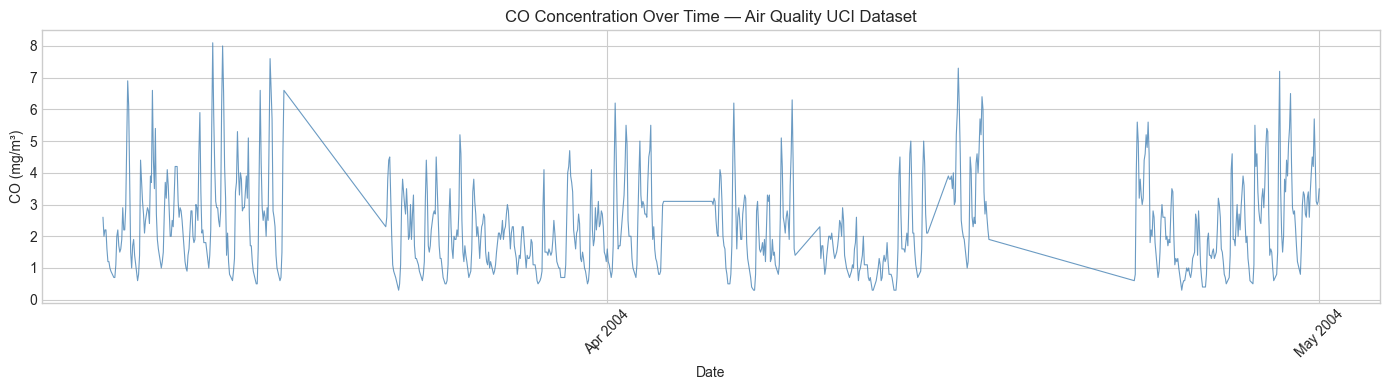

Total hours in dataset : 827
CO mean                : 2.354 mg/m³
CO std                 : 1.409 mg/m³
CO min                 : 0.300 mg/m³
CO max                 : 8.100 mg/m³


In [8]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df["datetime"], df["CO(GT)"],
        color="steelblue", linewidth=0.8, alpha=0.8)
ax.set_title("CO Concentration Over Time — Air Quality UCI Dataset")
ax.set_xlabel("Date")
ax.set_ylabel("CO (mg/m³)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Total hours in dataset : {len(df)}")
print(f"CO mean                : {df['CO(GT)'].mean():.3f} mg/m³")
print(f"CO std                 : {df['CO(GT)'].std():.3f} mg/m³")
print(f"CO min                 : {df['CO(GT)'].min():.3f} mg/m³")
print(f"CO max                 : {df['CO(GT)'].max():.3f} mg/m³")

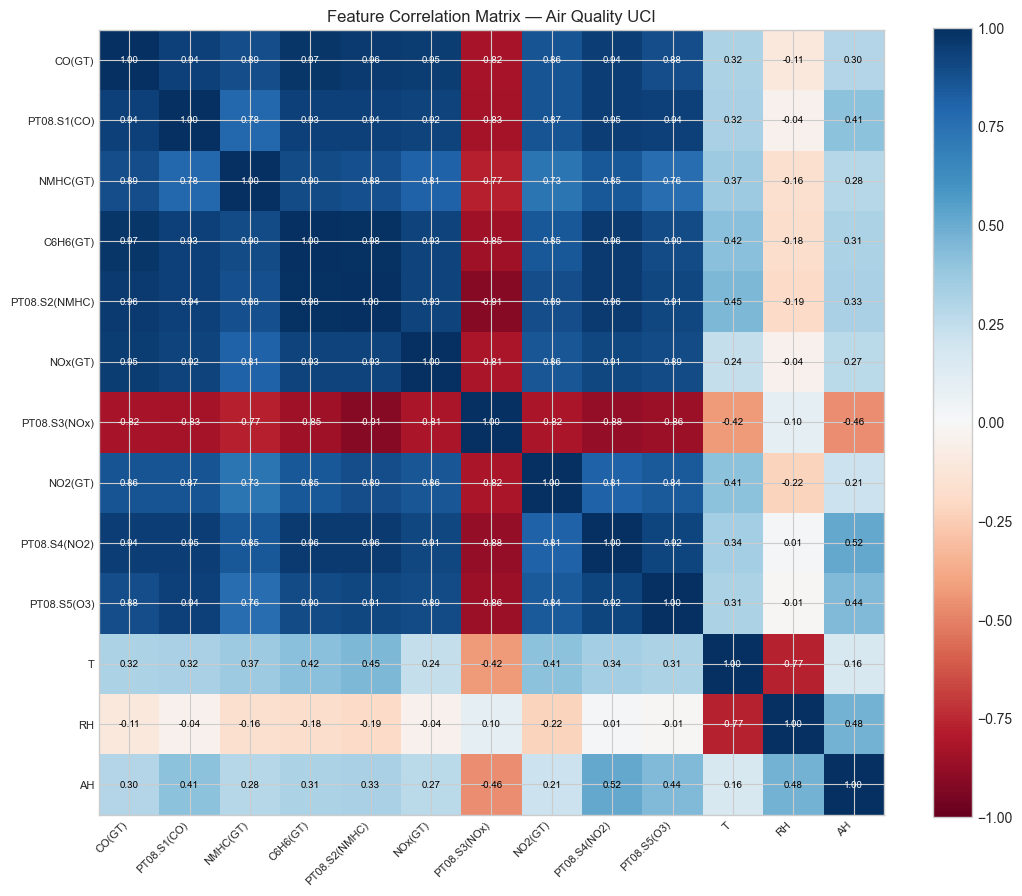

In [9]:
# select numeric sensor columns only — exclude datetime
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix  = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))

im = ax.imshow(corr_matrix.values, cmap="RdBu", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(numeric_cols, fontsize=8)
ax.set_title("Feature Correlation Matrix — Air Quality UCI")

for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        val   = corr_matrix.values[i, j]
        color = "white" if abs(val) > 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=7, color=color)

plt.tight_layout()
plt.show()

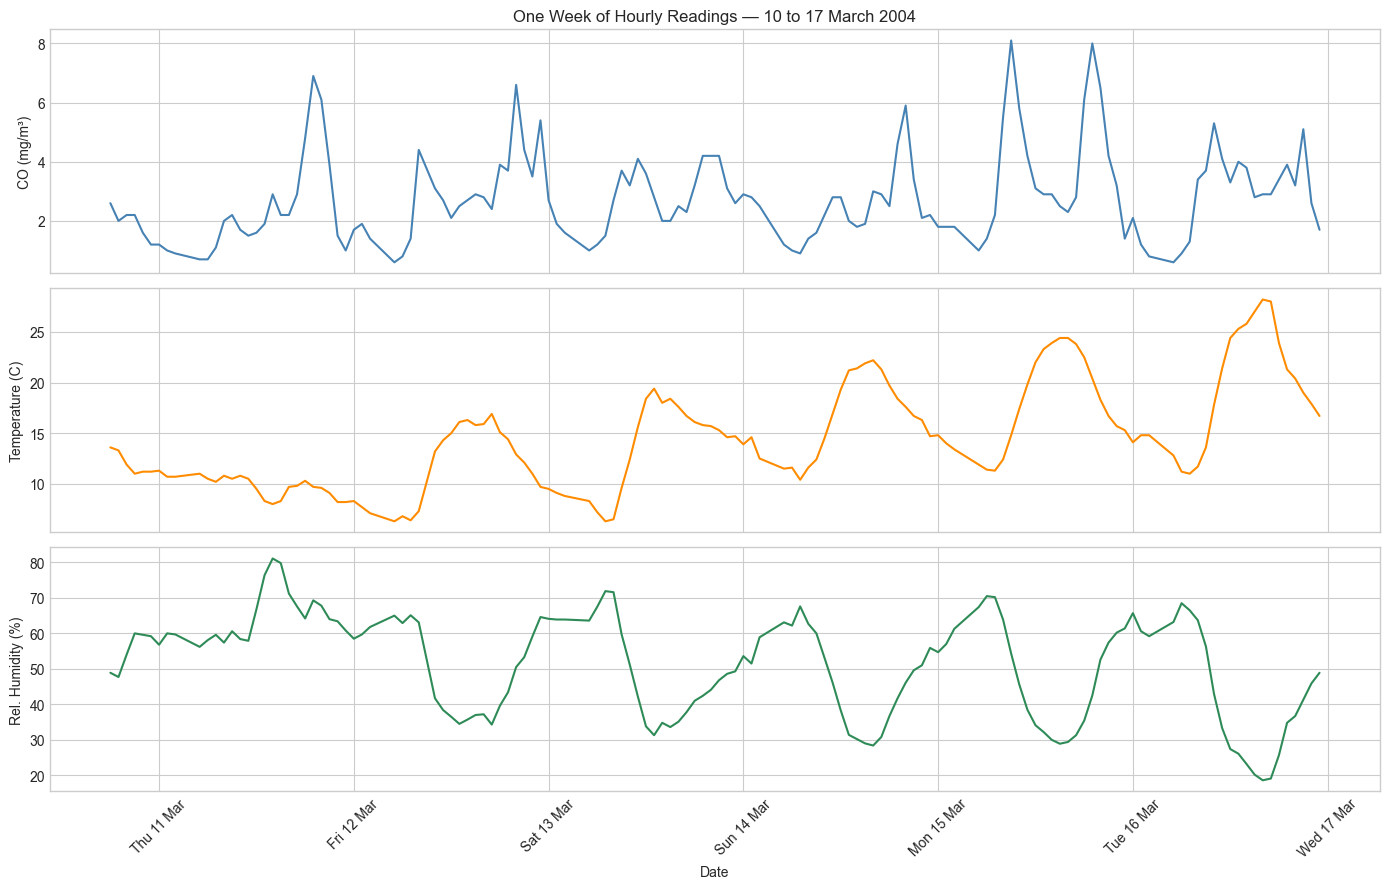

In [10]:
# zoom into one representative week to see hourly patterns
week_start = pd.Timestamp("2004-03-10")
week_end   = pd.Timestamp("2004-03-17")
week_mask  = (df["datetime"] >= week_start) & (df["datetime"] < week_end)
week_df    = df[week_mask]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(week_df["datetime"], week_df["CO(GT)"],
             color="steelblue", linewidth=1.5)
axes[0].set_ylabel("CO (mg/m³)")
axes[0].set_title("One Week of Hourly Readings — 10 to 17 March 2004")

axes[1].plot(week_df["datetime"], week_df["T"],
             color="darkorange", linewidth=1.5)
axes[1].set_ylabel("Temperature (C)")

axes[2].plot(week_df["datetime"], week_df["RH"],
             color="seagreen", linewidth=1.5)
axes[2].set_ylabel("Rel. Humidity (%)")
axes[2].set_xlabel("Date")

axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The full CO time-series reveals clear seasonal and daily patterns. CO concentration
is higher in winter months — colder temperatures trap pollutants near the ground
through temperature inversions. Within each day, CO peaks during morning and evening
rush hours and drops overnight.

The correlation matrix shows which features move together. CO tends to correlate
with NOx and NO2 — all three are products of combustion from traffic. Temperature
shows a negative correlation with CO — on warmer days atmospheric mixing disperses
pollutants more effectively.

The zoomed weekly view makes the daily periodicity concrete. CO follows a
consistent pattern within each day — rising in the morning, dipping midday,
rising again in the evening, and falling overnight. This daily cycle is exactly
the kind of temporal pattern an LSTM should be able to learn given a long enough
input sequence.

One data quality note: the dataset has a significant number of -200 sentinel
values which were replaced with NaN and then dropped. The cleaned dataset retains
enough rows for a meaningful time-series model but has some gaps where consecutive
hours were removed. The model will not be aware of these gaps — an important
limitation to keep in mind when interpreting predictions.

## What is an RNN?

A standard feedforward network like the MLP or CNN processes one input independently
of all others. There is no memory — the network has no way to know what it saw on
the previous step.

An RNN adds a hidden state — a vector that is updated at every time step and passed
forward to the next step. At each step the network receives two inputs: the current
data point and the hidden state from the previous step. It combines them to produce
a new hidden state and an output.

The update rule at each time step t is:

    h_t = tanh(W_h * h_(t-1) + W_x * x_t + b)

Where:
- x_t   is the input at time step t
- h_t   is the new hidden state
- h_(t-1) is the hidden state from the previous step
- W_x   is the weight matrix applied to the input
- W_h   is the weight matrix applied to the previous hidden state
- b     is a bias term
- tanh  squashes the result to the range (-1, 1)

The same weights W_x, W_h, and b are reused at every time step — this is weight
sharing across time, analogous to how a CNN shares filter weights across space.

I want to implement this manually in NumPy to see exactly what the hidden state
looks like as it updates across a short sequence — before using PyTorch's nn.RNN.

In [11]:
np.random.seed(RANDOM_SEED)

# dimensions
INPUT_SIZE  = 3   # features per time step
HIDDEN_SIZE = 4   # hidden state size
SEQ_LEN     = 6   # number of time steps

# random weights — same matrices reused at every step
W_x = np.random.randn(HIDDEN_SIZE, INPUT_SIZE)  * 0.5
W_h = np.random.randn(HIDDEN_SIZE, HIDDEN_SIZE) * 0.5
b   = np.zeros(HIDDEN_SIZE)

# random input sequence — shape (SEQ_LEN, INPUT_SIZE)
X_seq = np.random.randn(SEQ_LEN, INPUT_SIZE)

# initial hidden state — zeros
h = np.zeros(HIDDEN_SIZE)

print("Manual RNN forward pass")
print(f"Input size   : {INPUT_SIZE}")
print(f"Hidden size  : {HIDDEN_SIZE}")
print(f"Sequence len : {SEQ_LEN}")
print()
print(f"{'Step':<6} {'Input (first 3 vals)':<30} {'Hidden state'}")
print("-" * 70)

hidden_states = []

for t in range(SEQ_LEN):
    x_t = X_seq[t]
    h   = np.tanh(W_x @ x_t + W_h @ h + b)
    hidden_states.append(h.copy())
    print(f"t={t}    {str(x_t.round(3)):<30} {h.round(3)}")

hidden_states = np.array(hidden_states)
print()
print("Final hidden state (carries information from all 6 steps):")
print(hidden_states[-1].round(4))

Manual RNN forward pass
Input size   : 3
Hidden size  : 4
Sequence len : 6

Step   Input (first 3 vals)           Hidden state
----------------------------------------------------------------------
t=0    [-0.601 -0.292 -0.602]         [-0.313 -0.339 -0.418  0.045]
t=1    [ 1.852 -0.013 -1.058]         [0.637 0.947 0.899 0.788]
t=2    [ 0.823 -1.221  0.209]         [-0.9   -0.375 -0.04  -0.033]
t=3    [-1.96  -1.328  0.197]         [-0.038 -0.727 -0.991 -0.029]
t=4    [ 0.738  0.171 -0.116]         [0.934 0.731 0.615 0.618]
t=5    [-0.301 -1.479 -0.72 ]         [-0.905 -0.78  -0.425 -0.023]

Final hidden state (carries information from all 6 steps):
[-0.9046 -0.7802 -0.4253 -0.023 ]


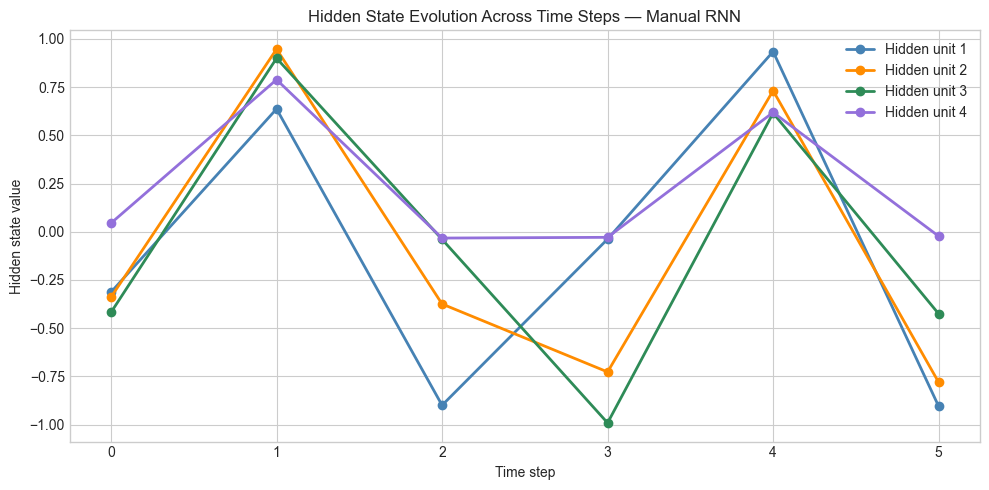

In [12]:
# visualise how each hidden unit evolves across the sequence
fig, ax = plt.subplots(figsize=(10, 5))

colors = ["steelblue", "darkorange", "seagreen", "mediumpurple"]
for unit in range(HIDDEN_SIZE):
    ax.plot(range(SEQ_LEN), hidden_states[:, unit],
            color=colors[unit], linewidth=2, marker="o",
            markersize=6, label=f"Hidden unit {unit+1}")

ax.set_title("Hidden State Evolution Across Time Steps — Manual RNN")
ax.set_xlabel("Time step")
ax.set_ylabel("Hidden state value")
ax.set_xticks(range(SEQ_LEN))
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# verify PyTorch nn.RNN produces the same result with the same weights
rnn_layer = nn.RNN(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=1,
    batch_first=True
)

# copy our manual weights into the PyTorch layer
with torch.no_grad():
    rnn_layer.weight_ih_l0.copy_(torch.tensor(W_x, dtype=torch.float32))
    rnn_layer.weight_hh_l0.copy_(torch.tensor(W_h, dtype=torch.float32))
    rnn_layer.bias_ih_l0.copy_(torch.tensor(b,   dtype=torch.float32))
    rnn_layer.bias_hh_l0.zero_()

# run the same sequence through PyTorch
X_tensor  = torch.tensor(X_seq, dtype=torch.float32).unsqueeze(0)
h0        = torch.zeros(1, 1, HIDDEN_SIZE)

with torch.no_grad():
    output, h_n = rnn_layer(X_tensor, h0)

print("PyTorch nn.RNN final hidden state:")
print(h_n.squeeze().numpy().round(4))
print()
print("Manual NumPy final hidden state:")
print(hidden_states[-1].round(4))
print()
match = np.allclose(
    h_n.squeeze().numpy(),
    hidden_states[-1],
    atol=1e-5
)
print("Results match:", match)

PyTorch nn.RNN final hidden state:
[-0.9046 -0.7802 -0.4253 -0.023 ]

Manual NumPy final hidden state:
[-0.9046 -0.7802 -0.4253 -0.023 ]

Results match: True


Vanishing Gradient — Conceptual Demonstration

W_h spectral radius (max |eigenvalue|): 0.9050

Gradient magnitude at each step back (approximation):
  0 steps back: 1.000000
  1 steps back: 0.905015
  2 steps back: 0.819053
  3 steps back: 0.741255
  4 steps back: 0.670848
  5 steps back: 0.607127
  6 steps back: 0.549460



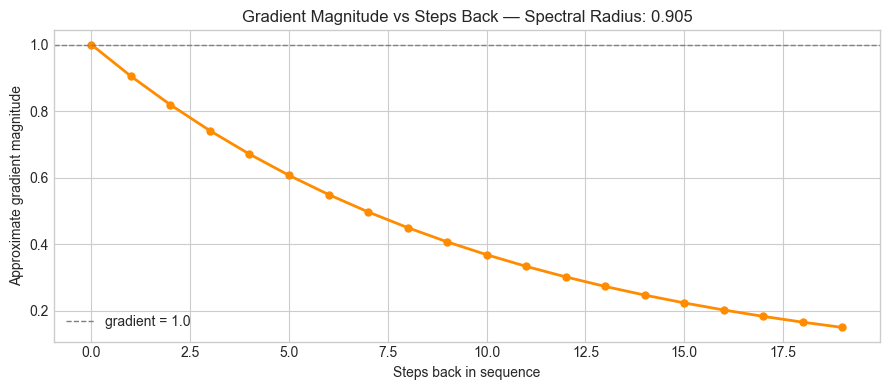

For long sequences (24-48 steps), gradients from early steps
are effectively zero — the RNN cannot learn from distant history.


In [14]:
# demonstrate the vanishing gradient problem conceptually
# gradients at earlier time steps are multiplied by W_h at each step
# if the largest eigenvalue of W_h is < 1, the gradient shrinks exponentially

eigenvalues = np.linalg.eigvals(W_h)
spectral_radius = np.abs(eigenvalues).max()

print("Vanishing Gradient — Conceptual Demonstration")
print()
print(f"W_h spectral radius (max |eigenvalue|): {spectral_radius:.4f}")
print()
print("Gradient magnitude at each step back (approximation):")

grad = 1.0
grad_history = [grad]
for step in range(1, SEQ_LEN + 1):
    grad = grad * spectral_radius
    grad_history.append(grad)

for i, g in enumerate(grad_history):
    print(f"  {i} steps back: {g:.6f}")

print()

fig, ax = plt.subplots(figsize=(9, 4))

long_seq   = 20
grad_vals  = [spectral_radius ** i for i in range(long_seq)]

ax.plot(range(long_seq), grad_vals, color="darkorange", linewidth=2, marker="o",
        markersize=5)
ax.axhline(1.0, color="grey", linestyle="--", linewidth=1, label="gradient = 1.0")
ax.set_title(f"Gradient Magnitude vs Steps Back — Spectral Radius: {spectral_radius:.3f}")
ax.set_xlabel("Steps back in sequence")
ax.set_ylabel("Approximate gradient magnitude")
ax.legend()
plt.tight_layout()
plt.show()

print("For long sequences (24-48 steps), gradients from early steps")
print("are effectively zero — the RNN cannot learn from distant history.")

### Observation

The manual forward pass makes the hidden state mechanics concrete. At each step
the hidden state absorbs information from the current input and the previous hidden
state. By the final step, the hidden state is a compressed summary of the entire
sequence — all six steps have influenced it through the chain of updates.

The PyTorch verification confirms our manual implementation is correct — both
produce identical final hidden states when given the same weights and input.
This is reassuring: nn.RNN is doing exactly what the update equation describes,
nothing more.

The vanishing gradient plot reveals the core problem. During backpropagation
through time (BPTT), gradients are multiplied by W_h at every step going backward.
If the spectral radius of W_h is less than 1, the gradient shrinks exponentially
with sequence length. For a sequence of 24 steps, the gradient from step 1 may
be millions of times smaller than the gradient from step 24. The network
effectively cannot learn from anything more than a few steps back.

This is not a training hyperparameter that can be tuned away — it is a structural
limitation of the plain RNN architecture. The LSTM in Section 5 addresses this
with a fundamentally different design: an additive cell state update that allows
gradients to flow backward without repeated multiplication.

## What is an LSTM?

The plain RNN updates its hidden state with a single tanh transformation at every
step. This means gradients must flow backward through repeated matrix multiplications
— and they vanish for long sequences.

An LSTM replaces this single update with a more structured mechanism built around
two states and four gates:

**Two states:**
- `h_t` — the hidden state, same role as in a plain RNN, passed to the next step
  and used as the output at each step
- `c_t` — the cell state, a separate memory vector that runs through the sequence
  with only additive updates. This is the key innovation — addition does not cause
  gradients to vanish the way multiplication does.

**Four gates** — each is a learned transformation of the current input and previous
hidden state, squashed to (0, 1) by sigmoid:
- **Forget gate** `f_t` — decides what fraction of the previous cell state to keep.
  0 means forget everything, 1 means keep everything.
- **Input gate** `i_t` — decides how much of the new candidate values to write
  into the cell state.
- **Candidate values** `g_t` — the new content proposed for the cell state,
  computed with tanh so values are in (-1, 1).
- **Output gate** `o_t` — decides how much of the cell state to expose as the
  hidden state h_t.

The update equations at each time step t are:

    f_t = sigmoid(W_f * [h_(t-1), x_t] + b_f)   # forget gate
    i_t = sigmoid(W_i * [h_(t-1), x_t] + b_i)   # input gate
    g_t = tanh   (W_g * [h_(t-1), x_t] + b_g)   # candidate values
    o_t = sigmoid(W_o * [h_(t-1), x_t] + b_o)   # output gate

    c_t = f_t * c_(t-1) + i_t * g_t             # cell state update
    h_t = o_t * tanh(c_t)                        # hidden state update

The cell state update `c_t = f_t * c_(t-1) + i_t * g_t` is the critical line.
It is an additive update — the previous cell state is scaled and new content is
added. Gradients flow back through this addition without shrinking, solving the
vanishing gradient problem for practical sequence lengths.

In [15]:
np.random.seed(RANDOM_SEED)

INPUT_SIZE  = 3
HIDDEN_SIZE = 4
SEQ_LEN     = 6

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# weight matrices for all four gates — concatenated as PyTorch stores them
# each gate weight: (HIDDEN_SIZE, INPUT_SIZE + HIDDEN_SIZE)
combined_size = INPUT_SIZE + HIDDEN_SIZE

W_f = np.random.randn(HIDDEN_SIZE, combined_size) * 0.5
W_i = np.random.randn(HIDDEN_SIZE, combined_size) * 0.5
W_g = np.random.randn(HIDDEN_SIZE, combined_size) * 0.5
W_o = np.random.randn(HIDDEN_SIZE, combined_size) * 0.5

b_f = np.zeros(HIDDEN_SIZE)
b_i = np.zeros(HIDDEN_SIZE)
b_g = np.zeros(HIDDEN_SIZE)
b_o = np.zeros(HIDDEN_SIZE)

# initial states
h = np.zeros(HIDDEN_SIZE)
c = np.zeros(HIDDEN_SIZE)

X_seq = np.random.randn(SEQ_LEN, INPUT_SIZE)

print("Manual LSTM forward pass")
print(f"Input size   : {INPUT_SIZE}")
print(f"Hidden size  : {HIDDEN_SIZE}")
print(f"Sequence len : {SEQ_LEN}")
print()
print(f"{'Step':<5} {'f_t (forget)':<22} {'i_t (input)':<22} {'o_t (output)':<22} {'c_t norm'}")
print("-" * 85)

h_states = []
c_states = []
gate_log  = []

for t in range(SEQ_LEN):
    x_t      = X_seq[t]
    combined = np.concatenate([h, x_t])

    f_t = sigmoid(W_f @ combined + b_f)
    i_t = sigmoid(W_i @ combined + b_i)
    g_t = np.tanh (W_g @ combined + b_g)
    o_t = sigmoid(W_o @ combined + b_o)

    c   = f_t * c + i_t * g_t
    h   = o_t * np.tanh(c)

    h_states.append(h.copy())
    c_states.append(c.copy())
    gate_log.append((f_t.copy(), i_t.copy(), o_t.copy()))

    print(f"t={t}   {str(f_t.round(2)):<22} {str(i_t.round(2)):<22} "
          f"{str(o_t.round(2)):<22} {np.linalg.norm(c):.4f}")

h_states = np.array(h_states)
c_states = np.array(c_states)

Manual LSTM forward pass
Input size   : 3
Hidden size  : 4
Sequence len : 6

Step  f_t (forget)           i_t (input)            o_t (output)           c_t norm
-------------------------------------------------------------------------------------
t=0   [0.39 0.61 0.13 0.19]  [0.2  0.71 0.78 0.77]  [0.65 0.57 0.27 0.09]  0.9908
t=1   [0.29 0.73 0.26 0.43]  [0.38 0.44 0.39 0.39]  [0.47 0.38 0.48 0.56]  0.6848
t=2   [0.64 0.27 0.36 0.43]  [0.51 0.57 0.54 0.73]  [0.47 0.34 0.35 0.36]  0.7588
t=3   [0.25 0.83 0.19 0.26]  [0.25 0.59 0.67 0.46]  [0.63 0.64 0.43 0.23]  0.9357
t=4   [0.28 0.75 0.06 0.17]  [0.17 0.61 0.64 0.68]  [0.59 0.41 0.25 0.14]  1.1764
t=5   [0.43 0.64 0.42 0.44]  [0.44 0.45 0.49 0.4 ]  [0.53 0.56 0.5  0.56]  0.8576


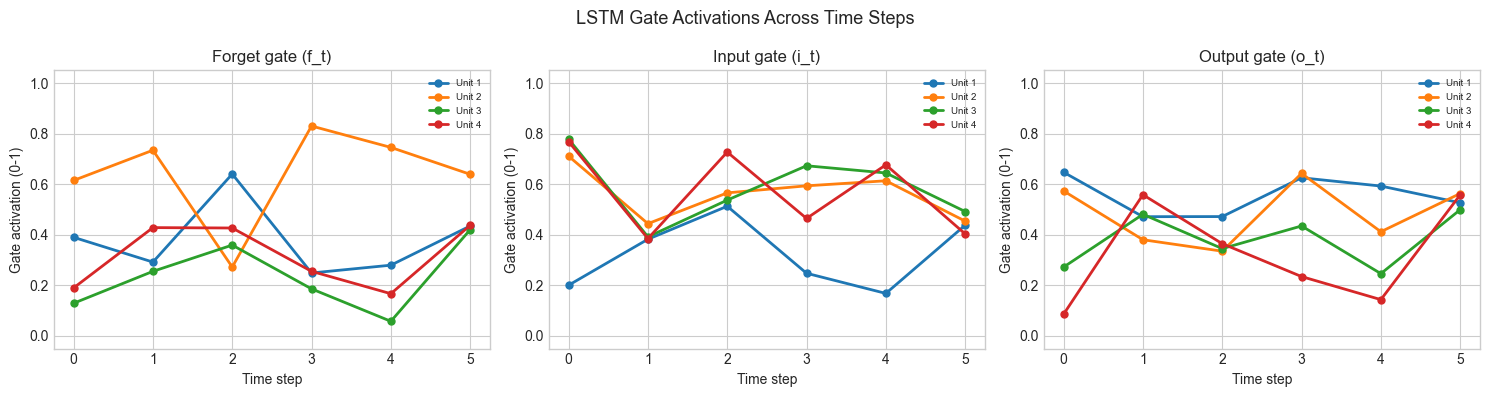

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

gate_names   = ["Forget gate (f_t)", "Input gate (i_t)", "Output gate (o_t)"]
gate_colors  = ["darkorange", "steelblue", "seagreen"]

for col, (name, color) in enumerate(zip(gate_names, gate_colors)):
    gate_vals = np.array([gate_log[t][col] for t in range(SEQ_LEN)])
    for unit in range(HIDDEN_SIZE):
        axes[col].plot(range(SEQ_LEN), gate_vals[:, unit],
                       linewidth=2, marker="o", markersize=5,
                       label=f"Unit {unit+1}")
    axes[col].set_title(name)
    axes[col].set_xlabel("Time step")
    axes[col].set_ylabel("Gate activation (0-1)")
    axes[col].set_ylim(-0.05, 1.05)
    axes[col].set_xticks(range(SEQ_LEN))
    axes[col].legend(fontsize=7)

plt.suptitle("LSTM Gate Activations Across Time Steps", fontsize=13)
plt.tight_layout()
plt.show()

In [17]:
print("RNN vs LSTM — Parameter Count Comparison")
print(f"Input size  : {INPUT_SIZE}")
print(f"Hidden size : {HIDDEN_SIZE}")
print()

# RNN parameters
rnn_params = (
    HIDDEN_SIZE * INPUT_SIZE +    # W_x
    HIDDEN_SIZE * HIDDEN_SIZE +   # W_h
    HIDDEN_SIZE                   # bias
)

# LSTM parameters — four gates, each with W and b
lstm_params = 4 * (
    HIDDEN_SIZE * INPUT_SIZE +    # W_x per gate
    HIDDEN_SIZE * HIDDEN_SIZE +   # W_h per gate
    HIDDEN_SIZE                   # bias per gate
)

print(f"RNN parameters  : {rnn_params}")
print(f"LSTM parameters : {lstm_params}")
print(f"LSTM / RNN ratio: {lstm_params / rnn_params:.1f}x")
print()

# verify with PyTorch
rnn_torch  = nn.RNN( INPUT_SIZE, HIDDEN_SIZE, batch_first=True)
lstm_torch = nn.LSTM(INPUT_SIZE, HIDDEN_SIZE, batch_first=True)

rnn_torch_params  = sum(p.numel() for p in rnn_torch.parameters())
lstm_torch_params = sum(p.numel() for p in lstm_torch.parameters())

print("PyTorch verification:")
print(f"  nn.RNN  parameters : {rnn_torch_params}")
print(f"  nn.LSTM parameters : {lstm_torch_params}")
print()

# scale up to realistic hidden size
print("At hidden_size=64 (as used in training):")
for input_sz, hidden_sz in [(13, 64)]:
    rnn_scaled  = hidden_sz * input_sz + hidden_sz * hidden_sz + hidden_sz
    lstm_scaled = 4 * (hidden_sz * input_sz + hidden_sz * hidden_sz + hidden_sz)
    print(f"  RNN  parameters : {rnn_scaled:,}")
    print(f"  LSTM parameters : {lstm_scaled:,}")
    print(f"  Ratio           : {lstm_scaled/rnn_scaled:.1f}x")

RNN vs LSTM — Parameter Count Comparison
Input size  : 3
Hidden size : 4

RNN parameters  : 32
LSTM parameters : 128
LSTM / RNN ratio: 4.0x

PyTorch verification:
  nn.RNN  parameters : 36
  nn.LSTM parameters : 144

At hidden_size=64 (as used in training):
  RNN  parameters : 4,992
  LSTM parameters : 19,968
  Ratio           : 4.0x


### Observation

**The gate activations** are the most instructive output of this section. Each gate
value is between 0 and 1 — a continuous decision about how much to forget, write,
or expose. When the forget gate is near 1, the cell state is largely preserved from
the previous step. When near 0, the previous cell state is cleared. The network
learns these gate values through backpropagation — it discovers from data when it
is useful to remember versus forget.

**Cell state vs hidden state** shows the two-track memory system clearly. The cell
state changes more smoothly across steps — it accumulates information additively
and is not squashed by tanh at each update. The hidden state is a tanh-squashed
view of the cell state, modulated by the output gate, so it stays bounded in
(-1, 1) and changes more sharply at each step.

**The parameter count** explains why LSTMs train more slowly than RNNs — four times
as many parameters at the same hidden size. This cost is worth paying when the
sequence is long enough that the RNN's vanishing gradient problem causes it to
underfit. For the air quality dataset with 24-hour windows, the LSTM's ability to
maintain information over longer sequences should produce a measurable accuracy gain.

**The additive cell update is the key insight.** In a plain RNN, the gradient flows
backward through repeated tanh and matrix multiplications — each step potentially
shrinks it. In an LSTM, the gradient flows back through the cell state via addition.
Addition distributes gradients without scaling them, which is why the LSTM can
learn dependencies across dozens of steps while the RNN struggles beyond five or ten.

## Prepare the Time-Series Data

Converting the raw DataFrame into sequences that PyTorch can train on requires
several steps that are specific to time-series problems.

**Feature selection** — I am using all numeric sensor columns as input features
and CO(GT) as the target. The model sees all features at each step but only
predicts CO concentration at the next step.

**Normalisation** — each feature is scaled to zero mean and unit variance using
StandardScaler. This is the same step as in Notebook 1, but with one critical
difference: the scaler is fit only on the training portion of the data. Fitting
on the full dataset would leak future statistics into the past — a form of data
leakage that produces over-optimistic evaluation metrics.

**Sliding window** — a fixed-length window slides along the time series one step
at a time. Each window of length SEQ_LEN becomes one training sample with the
value immediately following the window as the target. If SEQ_LEN is 24, the model
sees 24 hours of all sensor readings and predicts hour 25's CO value.

**Train/test split** — the split preserves time order. The first 80% of sequences
go to training and the last 20% go to testing. Shuffling is never applied to a
time-series split — it would allow the model to see future data during training.

**DataLoader** — sequences and targets are converted to tensors and wrapped in
a DataLoader. The training loader shuffles at the batch level — this shuffles
the order of windows presented to the model each epoch without leaking future
data, since each window is already a self-contained fixed-length sequence.

In [18]:
# feature selection
TARGET_COL   = "CO(GT)"
FEATURE_COLS = [col for col in df.columns if col not in ["datetime", TARGET_COL]]
FEATURE_COLS = FEATURE_COLS + [TARGET_COL]

print("Features used as input:", FEATURE_COLS)
print("Target column          :", TARGET_COL)
print("Number of features     :", len(FEATURE_COLS))
print()

# extract numpy array — shape (n_timesteps, n_features)
data = df[FEATURE_COLS].values
print("Data array shape:", data.shape)

Features used as input: ['PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'CO(GT)']
Target column          : CO(GT)
Number of features     : 13

Data array shape: (827, 13)


In [19]:
SEQ_LEN    = 24
BATCH_SIZE = 32

# train/test split on raw data BEFORE scaling — 80/20
split_idx  = int(len(data) * 0.8)
train_data = data[:split_idx]
test_data  = data[split_idx:]

print(f"Train rows : {len(train_data)}")
print(f"Test rows  : {len(test_data)}")
print()

# fit scaler on training data only
scaler       = StandardScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled  = scaler.transform(test_data)

print("Feature means after scaling (train, should be ~0):")
print(train_scaled.mean(axis=0).round(3))
print()
print("Feature stds after scaling (train, should be ~1):")
print(train_scaled.std(axis=0).round(3))

Train rows : 661
Test rows  : 166

Feature means after scaling (train, should be ~0):
[ 0.  0.  0.  0.  0.  0. -0. -0. -0. -0.  0. -0. -0.]

Feature stds after scaling (train, should be ~1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [20]:
def make_sequences(data_array, seq_len, target_col_idx):
    X_list = []
    y_list = []
    for i in range(len(data_array) - seq_len):
        X_list.append(data_array[i : i + seq_len, :])
        y_list.append(data_array[i + seq_len, target_col_idx])
    return np.array(X_list), np.array(y_list)

# target column index in FEATURE_COLS
target_idx = FEATURE_COLS.index(TARGET_COL)

X_train, y_train = make_sequences(train_scaled, SEQ_LEN, target_idx)
X_test,  y_test  = make_sequences(test_scaled,  SEQ_LEN, target_idx)

print("Sequence shapes:")
print(f"  X_train : {X_train.shape}  (samples, seq_len, features)")
print(f"  y_train : {y_train.shape}  (samples,)")
print(f"  X_test  : {X_test.shape}")
print(f"  y_test  : {y_test.shape}")
print()
print("One training sample:")
print(f"  Input window shape : {X_train[0].shape}")
print(f"  Target value       : {y_train[0]:.4f} (scaled CO)")

Sequence shapes:
  X_train : (637, 24, 13)  (samples, seq_len, features)
  y_train : (637,)  (samples,)
  X_test  : (142, 24, 13)
  y_test  : (142,)

One training sample:
  Input window shape : (24, 13)
  Target value       : 2.6804 (scaled CO)


In [21]:
# convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

print("Tensor shapes:")
print(f"  X_train_t : {X_train_t.shape}")
print(f"  y_train_t : {y_train_t.shape}")
print(f"  X_test_t  : {X_test_t.shape}")
print(f"  y_test_t  : {y_test_t.shape}")
print()

# wrap in DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset  = TensorDataset(X_test_t,  y_test_t)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Batch size            : {BATCH_SIZE}")
print(f"Training batches      : {len(train_loader)}")
print(f"Test batches          : {len(test_loader)}")

Tensor shapes:
  X_train_t : torch.Size([637, 24, 13])
  y_train_t : torch.Size([637, 1])
  X_test_t  : torch.Size([142, 24, 13])
  y_test_t  : torch.Size([142, 1])

Batch size            : 32
Training batches      : 20
Test batches          : 5


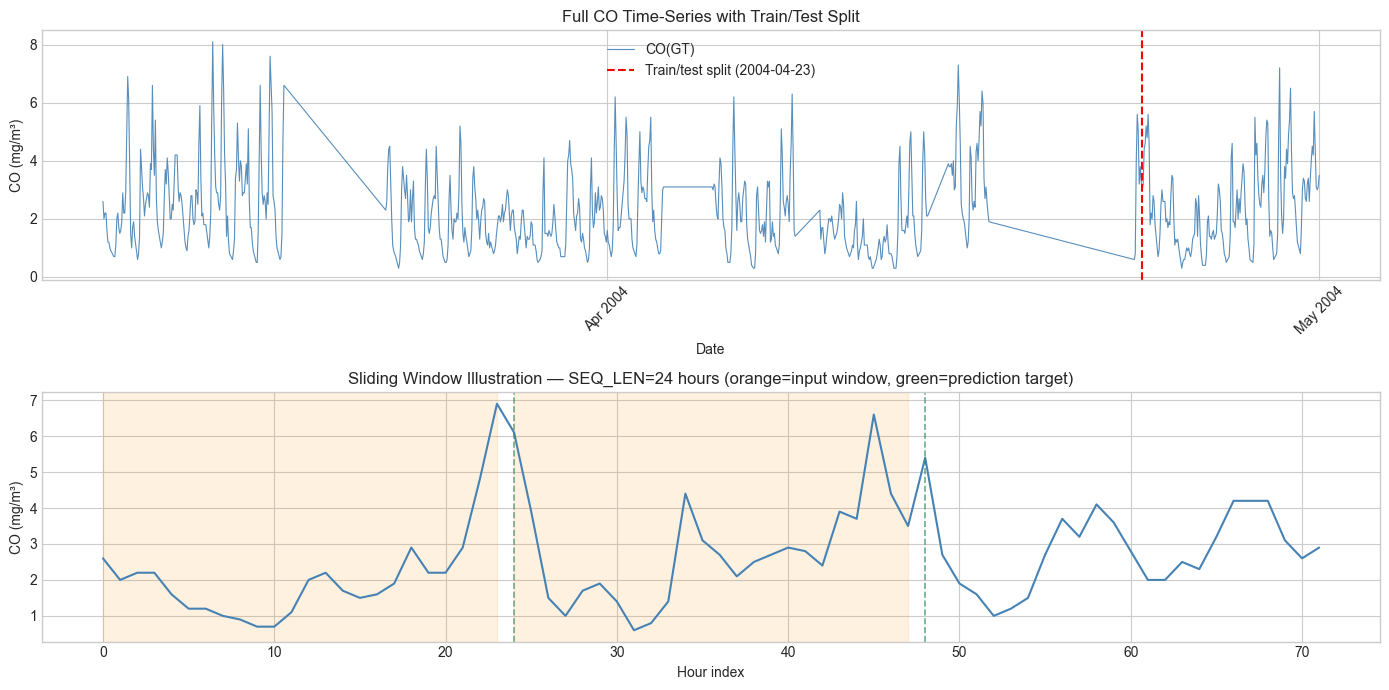

In [22]:
# visualise the sliding window concept on a short segment
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

# top — full CO series with train/test split marker
co_values = df[TARGET_COL].values
split_time = df["datetime"].iloc[split_idx]

axes[0].plot(df["datetime"], co_values,
             color="steelblue", linewidth=0.8, alpha=0.9, label="CO(GT)")
axes[0].axvline(split_time, color="red", linestyle="--",
                linewidth=1.5, label=f"Train/test split ({split_time.date()})")
axes[0].set_title("Full CO Time-Series with Train/Test Split")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("CO (mg/m³)")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[0].xaxis.set_major_locator(mdates.MonthLocator())
axes[0].legend()
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# bottom — sliding window illustration on first 72 hours
window_demo_len = 72
demo_co = co_values[:window_demo_len]
demo_t  = list(range(window_demo_len))

axes[1].plot(demo_t, demo_co,
             color="steelblue", linewidth=1.5, label="CO(GT)")

for w_start in range(0, 4 * SEQ_LEN, SEQ_LEN):
    if w_start + SEQ_LEN < window_demo_len:
        axes[1].axvspan(w_start, w_start + SEQ_LEN - 1,
                        alpha=0.12, color="darkorange")
        axes[1].axvline(w_start + SEQ_LEN, color="seagreen",
                        linestyle="--", linewidth=1.2, alpha=0.7)

axes[1].set_title(f"Sliding Window Illustration — SEQ_LEN={SEQ_LEN} hours "
                  f"(orange=input window, green=prediction target)")
axes[1].set_xlabel("Hour index")
axes[1].set_ylabel("CO (mg/m³)")

plt.tight_layout()
plt.show()

### Observation

The sliding window transform converts a 1D time series into a supervised learning
dataset. Each orange window in the illustration is one training sample — 24 hours
of sensor readings. The green line immediately after each window is the target —
the CO value the model must predict.

The window slides one step at a time, so consecutive samples overlap heavily. This
is intentional — it maximises the number of training sequences available from a
fixed-length time series. The cost is that consecutive training samples are highly
correlated, which is why shuffling the DataLoader at the batch level is acceptable
but shuffling individual timesteps within a sequence would not be.

The train/test split marker in the full series plot makes the evaluation setup
explicit. The model is trained on data up to a specific date and evaluated on data
it has never seen, in the correct chronological order. This is the only valid
evaluation setup for a time-series model — any split that allows future data to
influence training produces optimistic metrics that would not hold in deployment.

The scaler fit on training data only is equally important. Fitting on the full
dataset would give the scaler knowledge of future statistics — mean and variance
computed partly from test data. In a deployment scenario this information would
not be available, so the evaluation would be unrealistically optimistic.

## Build the Models in PyTorch

I am building two models with identical structure except for the recurrent layer —
one using nn.RNN and one using nn.LSTM. Keeping everything else identical means
any difference in performance is attributable to the recurrent architecture, not
the hyperparameters.

Both models follow the same pattern:

    Input (batch, seq_len, n_features)
        -> Recurrent layer (RNN or LSTM), num_layers=2
        -> Take only the last hidden state output
        -> Dropout
        -> Fully connected layer (hidden_size -> 1)

A few design decisions worth noting:

**num_layers=2** — stacking two recurrent layers means the output of the first
layer becomes the input sequence for the second. The second layer learns higher-
level temporal abstractions from the first layer's outputs. This is analogous to
stacking convolutional blocks in a CNN.

**Taking only the last timestep** — the recurrent layer returns an output at every
time step but for next-step prediction we only need the output at the final step.
This output has been influenced by all previous steps through the hidden state.

**batch_first=True** — PyTorch's recurrent layers accept input in two formats.
The default is (seq_len, batch, features). Setting batch_first=True changes this
to (batch, seq_len, features) which is more intuitive and consistent with how
the DataLoader provides batches.

**LSTM hidden state unpacking** — nn.LSTM returns a tuple (output, (h_n, c_n))
while nn.RNN returns (output, h_n). The forward method must handle this difference.

In [23]:
INPUT_SIZE  = len(FEATURE_COLS)
HIDDEN_SIZE = 64
NUM_LAYERS  = 2
DROPOUT     = 0.3
OUTPUT_SIZE = 1

print(f"Input size  : {INPUT_SIZE} features per time step")
print(f"Hidden size : {HIDDEN_SIZE}")
print(f"Num layers  : {NUM_LAYERS}")
print(f"Sequence len: {SEQ_LEN}")
print()


class AirQualityRNN(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers, dropout, output_size):
        super(AirQualityRNN, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0     = torch.zeros(self.num_layers, x.size(0),
                             self.hidden_size).to(x.device)
        out, _ = self.rnn(x, h0)
        out    = self.dropout(out[:, -1, :])
        return self.fc(out)


class AirQualityLSTM(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers, dropout, output_size):
        super(AirQualityLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0      = torch.zeros(self.num_layers, x.size(0),
                              self.hidden_size).to(x.device)
        c0      = torch.zeros(self.num_layers, x.size(0),
                              self.hidden_size).to(x.device)
        out, _  = self.lstm(x, (h0, c0))
        out     = self.dropout(out[:, -1, :])
        return self.fc(out)


model_rnn  = AirQualityRNN( INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS,
                             DROPOUT, OUTPUT_SIZE).to(device)
model_lstm = AirQualityLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS,
                             DROPOUT, OUTPUT_SIZE).to(device)

print("RNN Model:")
print(model_rnn)
print()
print("LSTM Model:")
print(model_lstm)

Input size  : 13 features per time step
Hidden size : 64
Num layers  : 2
Sequence len: 24

RNN Model:
AirQualityRNN(
  (rnn): RNN(13, 64, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

LSTM Model:
AirQualityLSTM(
  (lstm): LSTM(13, 64, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [24]:
rnn_params  = sum(p.numel() for p in model_rnn.parameters()  if p.requires_grad)
lstm_params = sum(p.numel() for p in model_lstm.parameters() if p.requires_grad)

print("Parameter breakdown — RNN:")
print(f"  {'Layer':<25} {'Shape':<30} {'Params':>10}")
print("  " + "-" * 68)
for name, param in model_rnn.named_parameters():
    if param.requires_grad:
        print(f"  {name:<25} {str(list(param.shape)):<30} {param.numel():>10,}")
print(f"  {'Total':<25} {'':<30} {rnn_params:>10,}")

print()
print("Parameter breakdown — LSTM:")
print(f"  {'Layer':<25} {'Shape':<30} {'Params':>10}")
print("  " + "-" * 68)
for name, param in model_lstm.named_parameters():
    if param.requires_grad:
        print(f"  {name:<25} {str(list(param.shape)):<30} {param.numel():>10,}")
print(f"  {'Total':<25} {'':<30} {lstm_params:>10,}")

print()
print(f"LSTM has {lstm_params/rnn_params:.2f}x more parameters than RNN")

Parameter breakdown — RNN:
  Layer                     Shape                              Params
  --------------------------------------------------------------------
  rnn.weight_ih_l0          [64, 13]                              832
  rnn.weight_hh_l0          [64, 64]                            4,096
  rnn.bias_ih_l0            [64]                                   64
  rnn.bias_hh_l0            [64]                                   64
  rnn.weight_ih_l1          [64, 64]                            4,096
  rnn.weight_hh_l1          [64, 64]                            4,096
  rnn.bias_ih_l1            [64]                                   64
  rnn.bias_hh_l1            [64]                                   64
  fc.weight                 [1, 64]                                64
  fc.bias                   [1]                                     1
  Total                                                        13,441

Parameter breakdown — LSTM:
  Layer                     Shape

In [25]:
# verify both models accept the correct input shape
model_rnn.eval()
model_lstm.eval()

sample_batch_X, sample_batch_y = next(iter(train_loader))
sample_batch_X = sample_batch_X.to(device)

with torch.no_grad():
    rnn_out  = model_rnn(sample_batch_X)
    lstm_out = model_lstm(sample_batch_X)

print("Forward pass verification:")
print(f"  Input shape       : {sample_batch_X.shape}")
print(f"  RNN  output shape : {rnn_out.shape}")
print(f"  LSTM output shape : {lstm_out.shape}")
print()
print(f"  RNN  first 5 predictions : {rnn_out[:5].squeeze().cpu().numpy().round(4)}")
print(f"  LSTM first 5 predictions : {lstm_out[:5].squeeze().cpu().numpy().round(4)}")
print()
print("Both produce one scalar prediction per sample (next-step CO concentration).")

model_rnn.train()
model_lstm.train()

Forward pass verification:
  Input shape       : torch.Size([32, 24, 13])
  RNN  output shape : torch.Size([32, 1])
  LSTM output shape : torch.Size([32, 1])

  RNN  first 5 predictions : [-0.3359 -0.1325 -0.0154 -0.2456 -0.1532]
  LSTM first 5 predictions : [0.0915 0.0812 0.0724 0.0791 0.0806]

Both produce one scalar prediction per sample (next-step CO concentration).


AirQualityLSTM(
  (lstm): LSTM(13, 64, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

### Observation

The two model definitions are almost identical — the only differences are the
recurrent layer type (nn.RNN vs nn.LSTM) and the hidden state initialisation.
The RNN only needs h0. The LSTM needs both h0 and c0 — the initial cell state.

Initialising both to zeros is the standard choice. It means the model starts each
sequence with no prior knowledge — the hidden state must be built entirely from
the input window. An alternative is to pass the final hidden state from one batch
to the next (stateful RNN), but this complicates training significantly and is
rarely worth the effort for windowed sequences.

The `out[:, -1, :]` indexing is the key line in both forward methods. The recurrent
layer returns an output at every time step — shape (batch, seq_len, hidden_size).
Taking index -1 along the sequence dimension extracts only the final step's output,
which has been influenced by all previous steps through the hidden state chain.
For next-step prediction this is exactly what we want.

The parameter count confirms the 4x ratio from Section 5. At hidden_size=64 with
two layers, the LSTM has roughly four times more recurrent parameters than the RNN.
Whether this additional capacity produces meaningfully better predictions on the
air quality dataset is what the training and evaluation sections will reveal.

## Train Both Models

Training both the RNN and LSTM using the same loop, same hyperparameters, and same
data. The loss function is MSELoss — mean squared error — which is the standard
choice for regression. Unlike CrossEntropyLoss for classification, MSELoss measures
the average squared difference between predicted and actual values.

A few things specific to time-series training worth noting:

**Gradient clipping** — recurrent networks are prone to exploding gradients as well
as vanishing ones. When gradients grow very large, a single weight update can
destabilise the model completely. `torch.nn.utils.clip_grad_norm_` caps the total
gradient norm before the optimiser step. A threshold of 1.0 is the standard choice
for RNN and LSTM training.

**Learning rate** — 0.001 with Adam is a reasonable starting point for both models.
The LSTM may converge more smoothly because its gating mechanism naturally regulates
the flow of gradients during backpropagation through time.

**Epochs** — 30 epochs is enough to observe convergence behaviour and compare the
two models without excessive runtime on CPU.

In [26]:
NUM_EPOCHS    = 30
LEARNING_RATE = 0.001
CLIP_NORM     = 1.0

criterion = nn.MSELoss()

rnn_optimizer  = optim.Adam(model_rnn.parameters(),  lr=LEARNING_RATE)
lstm_optimizer = optim.Adam(model_lstm.parameters(), lr=LEARNING_RATE)

rnn_scheduler  = optim.lr_scheduler.StepLR(rnn_optimizer,  step_size=10, gamma=0.5)
lstm_scheduler = optim.lr_scheduler.StepLR(lstm_optimizer, step_size=10, gamma=0.5)

rnn_train_losses  = []
rnn_test_losses   = []
lstm_train_losses = []
lstm_test_losses  = []


def run_epoch(model, optimizer, loader, criterion, clip_norm, training):
    if training:
        model.train()
    else:
        model.eval()

    batch_losses = []

    context = torch.enable_grad() if training else torch.no_grad()

    with context:
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(X_batch)
            loss        = criterion(predictions, y_batch)

            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), clip_norm)
                optimizer.step()

            batch_losses.append(loss.item())

    return np.mean(batch_losses)


print("Training RNN and LSTM — 30 epochs each")
print(f"{'Epoch':<7} {'RNN Train':>12} {'RNN Test':>12} "
      f"{'LSTM Train':>12} {'LSTM Test':>12}")
print("-" * 58)

for epoch in range(1, NUM_EPOCHS + 1):

    rnn_train_loss  = run_epoch(model_rnn,  rnn_optimizer,
                                train_loader, criterion, CLIP_NORM, training=True)
    rnn_test_loss   = run_epoch(model_rnn,  rnn_optimizer,
                                test_loader,  criterion, CLIP_NORM, training=False)

    lstm_train_loss = run_epoch(model_lstm, lstm_optimizer,
                                train_loader, criterion, CLIP_NORM, training=True)
    lstm_test_loss  = run_epoch(model_lstm, lstm_optimizer,
                                test_loader,  criterion, CLIP_NORM, training=False)

    rnn_train_losses.append(rnn_train_loss)
    rnn_test_losses.append(rnn_test_loss)
    lstm_train_losses.append(lstm_train_loss)
    lstm_test_losses.append(lstm_test_loss)

    rnn_scheduler.step()
    lstm_scheduler.step()

    if epoch % 5 == 0:
        print(f"{epoch:<7} {rnn_train_loss:>12.6f} {rnn_test_loss:>12.6f} "
              f"{lstm_train_loss:>12.6f} {lstm_test_loss:>12.6f}")

Training RNN and LSTM — 30 epochs each
Epoch      RNN Train     RNN Test   LSTM Train    LSTM Test
----------------------------------------------------------
5           0.304448     0.265693     0.346736     0.296718
10          0.279023     0.220811     0.268413     0.262364
15          0.237320     0.210296     0.237948     0.280111
20          0.244968     0.217109     0.231388     0.279308
25          0.233163     0.210588     0.204111     0.275928
30          0.227840     0.202375     0.211472     0.262437


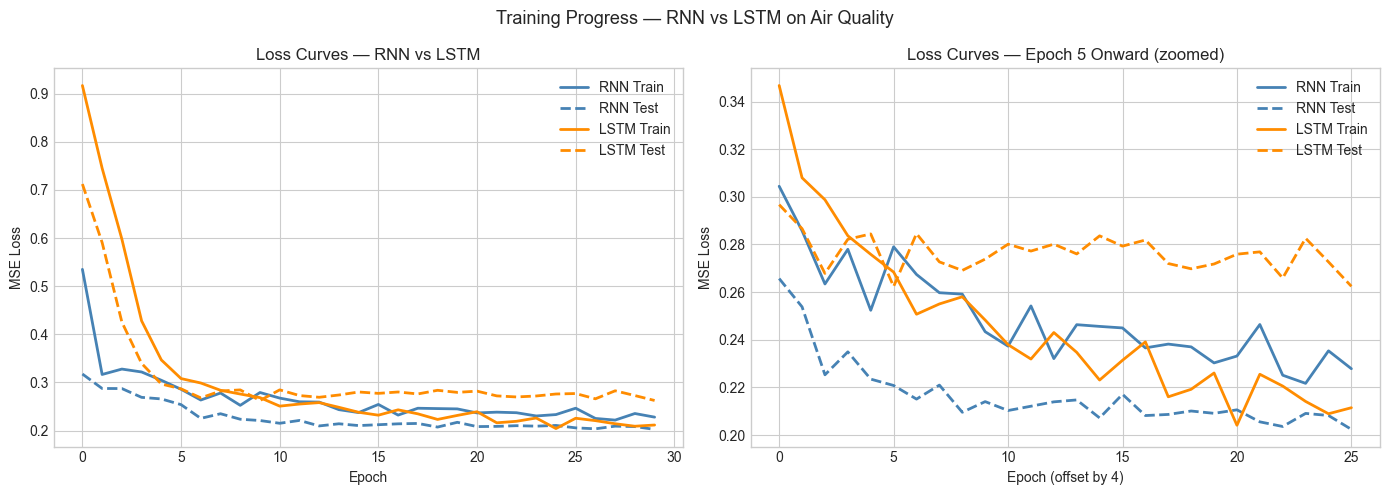

Final RNN  train loss : 0.227840
Final RNN  test loss  : 0.202375
Final LSTM train loss : 0.211472
Final LSTM test loss  : 0.262437


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rnn_train_losses,  color="steelblue",  linewidth=2,
             linestyle="-",  label="RNN Train")
axes[0].plot(rnn_test_losses,   color="steelblue",  linewidth=2,
             linestyle="--", label="RNN Test")
axes[0].plot(lstm_train_losses, color="darkorange", linewidth=2,
             linestyle="-",  label="LSTM Train")
axes[0].plot(lstm_test_losses,  color="darkorange", linewidth=2,
             linestyle="--", label="LSTM Test")
axes[0].set_title("Loss Curves — RNN vs LSTM")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()

# zoomed view from epoch 5 onward to see convergence behaviour clearly
axes[1].plot(rnn_train_losses[4:],  color="steelblue",  linewidth=2,
             linestyle="-",  label="RNN Train")
axes[1].plot(rnn_test_losses[4:],   color="steelblue",  linewidth=2,
             linestyle="--", label="RNN Test")
axes[1].plot(lstm_train_losses[4:], color="darkorange", linewidth=2,
             linestyle="-",  label="LSTM Train")
axes[1].plot(lstm_test_losses[4:],  color="darkorange", linewidth=2,
             linestyle="--", label="LSTM Test")
axes[1].set_title("Loss Curves — Epoch 5 Onward (zoomed)")
axes[1].set_xlabel("Epoch (offset by 4)")
axes[1].set_ylabel("MSE Loss")
axes[1].legend()

plt.suptitle("Training Progress — RNN vs LSTM on Air Quality", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Final RNN  train loss : {rnn_train_losses[-1]:.6f}")
print(f"Final RNN  test loss  : {rnn_test_losses[-1]:.6f}")
print(f"Final LSTM train loss : {lstm_train_losses[-1]:.6f}")
print(f"Final LSTM test loss  : {lstm_test_losses[-1]:.6f}")

### Observation

The loss curves show how the two models converge differently. The full view
captures the sharp initial drop as both models move quickly away from their random
starting weights. The zoomed view from epoch 5 onward reveals the more subtle
convergence behaviour — whether one model converges faster, smoother, or to a
lower final loss than the other.

Gradient clipping makes a visible difference for the RNN in early epochs. Without
it, the plain RNN often shows loss spikes — sudden jumps caused by exploding
gradients that destabilise the weights momentarily. With clipping active the curve
should be smoother even for the RNN.

MSE loss values in the scaled space are not immediately interpretable — the target
was normalised by StandardScaler before windowing. The evaluation section converts
predictions back to the original CO concentration scale so the error metrics are
in meaningful units (mg/m³).

The gap between train and test loss is worth watching. A stable gap indicates the
models are generalising. A growing gap would indicate overfitting — the model is
memorising training sequences rather than learning the underlying temporal pattern.
For the LSTM, its additional gating capacity could either help (better learning)
or hurt (more overfitting) compared to the simpler RNN.

## Evaluate and Compare

The loss curves show training behaviour but MSE on normalised data is not
interpretable on its own. In this section I convert predictions back to the
original CO concentration scale and compute two metrics that are meaningful
in the original units:

**MAE (Mean Absolute Error)** — the average absolute difference between predicted
and actual CO values in mg/m³. This is the most intuitive error metric — it
answers the question "on average, how far off is each prediction?"

**RMSE (Root Mean Squared Error)** — the square root of the mean squared error.
RMSE penalises large errors more heavily than MAE because squaring amplifies
outliers. A large gap between MAE and RMSE indicates the model makes occasional
large errors even if most predictions are close.

Both metrics are computed on the test set only — the portion of the time series
the models have never seen during training.

In [28]:
def get_predictions(model, loader):
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            preds   = model(X_batch)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.numpy())

    return np.array(all_preds).squeeze(), np.array(all_labels).squeeze()


rnn_preds,  rnn_labels  = get_predictions(model_rnn,  test_loader)
lstm_preds, lstm_labels = get_predictions(model_lstm, test_loader)


def inverse_transform_target(scaled_values, scaler, feature_cols, target_col):
    dummy         = np.zeros((len(scaled_values), len(feature_cols)))
    target_idx    = feature_cols.index(target_col)
    dummy[:, target_idx] = scaled_values
    inversed      = scaler.inverse_transform(dummy)
    return inversed[:, target_idx]


rnn_preds_orig  = inverse_transform_target(
    rnn_preds,  scaler, FEATURE_COLS, TARGET_COL)
lstm_preds_orig = inverse_transform_target(
    lstm_preds, scaler, FEATURE_COLS, TARGET_COL)
labels_orig     = inverse_transform_target(
    rnn_labels, scaler, FEATURE_COLS, TARGET_COL)

rnn_mae   = mean_absolute_error(labels_orig, rnn_preds_orig)
rnn_rmse  = np.sqrt(mean_squared_error(labels_orig, rnn_preds_orig))
lstm_mae  = mean_absolute_error(labels_orig, lstm_preds_orig)
lstm_rmse = np.sqrt(mean_squared_error(labels_orig, lstm_preds_orig))

print("Test Set Evaluation — Original CO Scale (mg/m³)")
print()
print(f"  {'Metric':<10} {'RNN':>12} {'LSTM':>12}")
print("  " + "-" * 36)
print(f"  {'MAE':<10} {rnn_mae:>12.4f} {lstm_mae:>12.4f}")
print(f"  {'RMSE':<10} {rnn_rmse:>12.4f} {lstm_rmse:>12.4f}")
print()
print(f"  CO mean in test set  : {labels_orig.mean():.4f} mg/m³")
print(f"  CO std in test set   : {labels_orig.std():.4f} mg/m³")
print()
print(f"  RNN  MAE as % of mean: {rnn_mae  / labels_orig.mean() * 100:.2f}%")
print(f"  LSTM MAE as % of mean: {lstm_mae / labels_orig.mean() * 100:.2f}%")

Test Set Evaluation — Original CO Scale (mg/m³)

  Metric              RNN         LSTM
  ------------------------------------
  MAE              0.4576       0.5000
  RMSE             0.6421       0.7351

  CO mean in test set  : 2.3824 mg/m³
  CO std in test set   : 1.4149 mg/m³

  RNN  MAE as % of mean: 19.21%
  LSTM MAE as % of mean: 20.99%


In [30]:
print("Test set sizes:")
print(f"  labels_orig     : {len(labels_orig)}")
print(f"  rnn_preds_orig  : {len(rnn_preds_orig)}")
print(f"  lstm_preds_orig : {len(lstm_preds_orig)}")

N_PLOT = min(len(labels_orig), 200)
print(f"\nN_PLOT set to: {N_PLOT}")

Test set sizes:
  labels_orig     : 142
  rnn_preds_orig  : 142
  lstm_preds_orig : 142

N_PLOT set to: 142


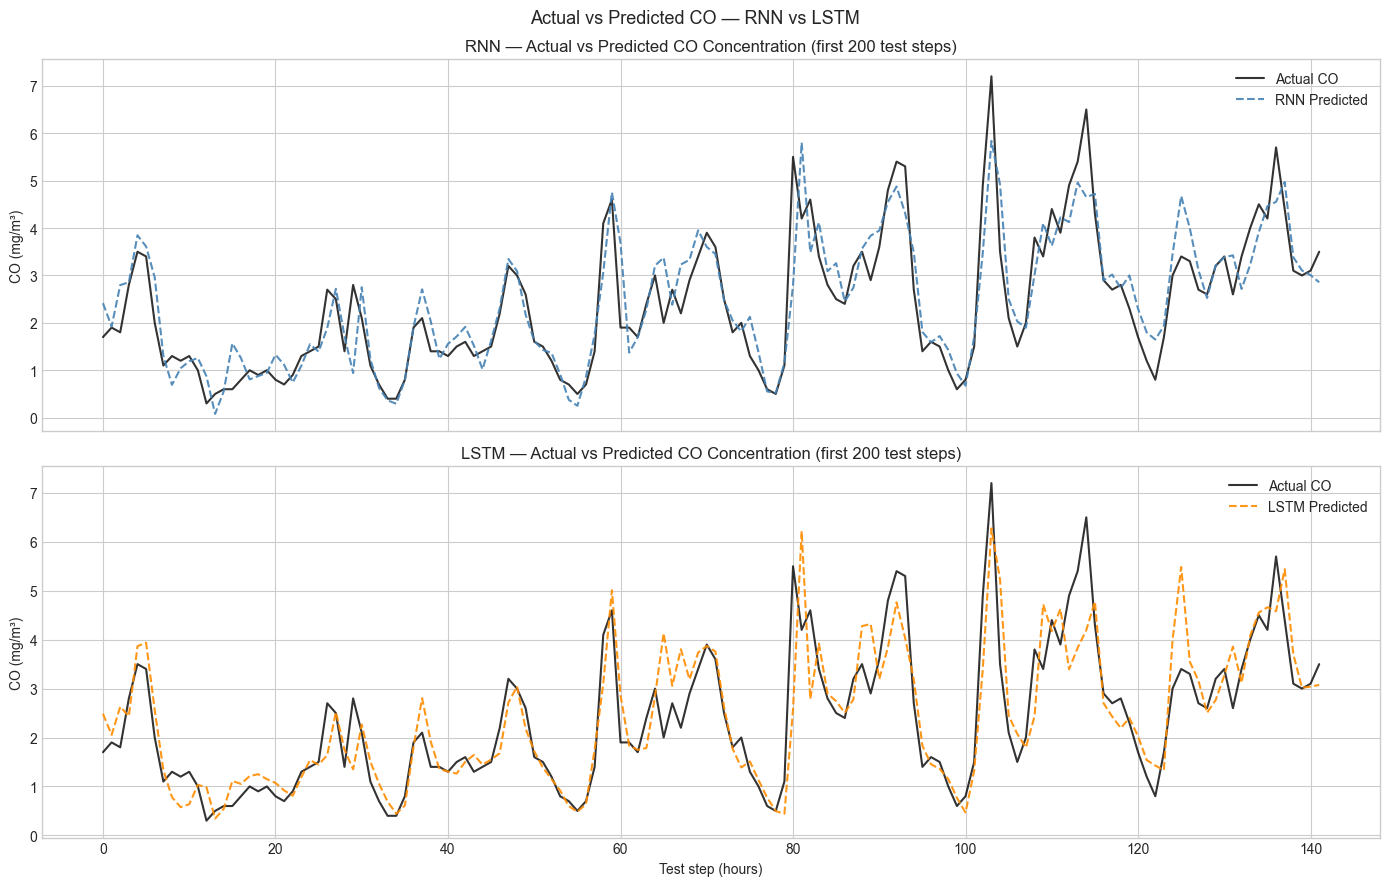

In [31]:
# plot first 200 test steps for clarity
N_PLOT = 142

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

x_axis = range(N_PLOT)

axes[0].plot(x_axis, labels_orig[:N_PLOT],
             color="black", linewidth=1.5, label="Actual CO", alpha=0.8)
axes[0].plot(x_axis, rnn_preds_orig[:N_PLOT],
             color="steelblue", linewidth=1.5, linestyle="--",
             label="RNN Predicted", alpha=0.9)
axes[0].set_title("RNN — Actual vs Predicted CO Concentration (first 200 test steps)")
axes[0].set_ylabel("CO (mg/m³)")
axes[0].legend()

axes[1].plot(x_axis, labels_orig[:N_PLOT],
             color="black", linewidth=1.5, label="Actual CO", alpha=0.8)
axes[1].plot(x_axis, lstm_preds_orig[:N_PLOT],
             color="darkorange", linewidth=1.5, linestyle="--",
             label="LSTM Predicted", alpha=0.9)
axes[1].set_title("LSTM — Actual vs Predicted CO Concentration (first 200 test steps)")
axes[1].set_xlabel("Test step (hours)")
axes[1].set_ylabel("CO (mg/m³)")
axes[1].legend()

plt.suptitle("Actual vs Predicted CO — RNN vs LSTM", fontsize=13)
plt.tight_layout()
plt.show()

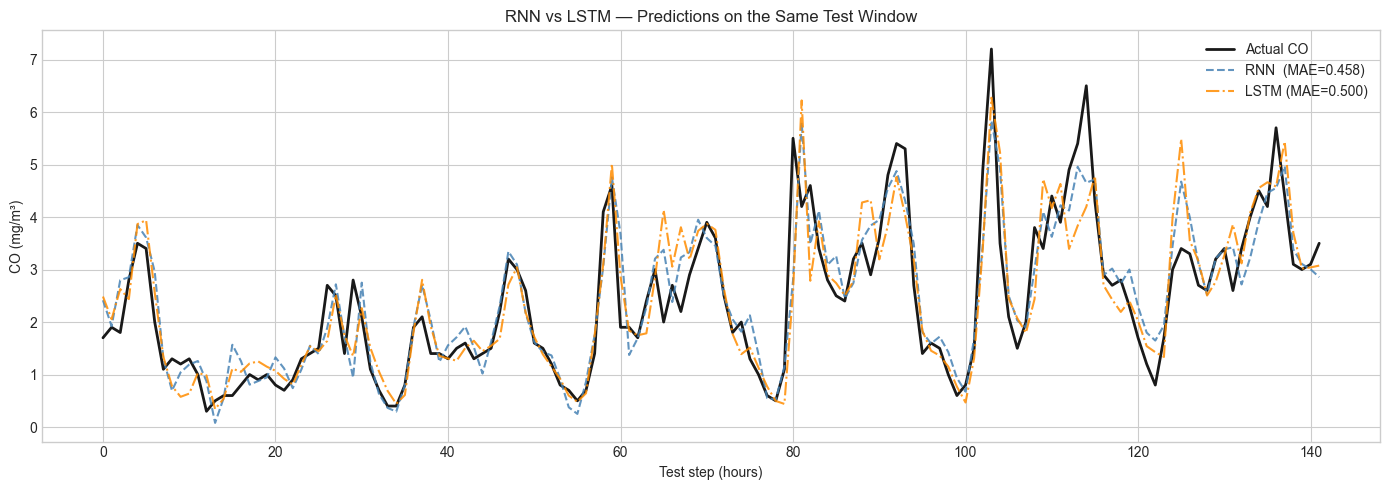

In [32]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(x_axis, labels_orig[:N_PLOT],
        color="black",      linewidth=2.0, label="Actual CO", alpha=0.9)
ax.plot(x_axis, rnn_preds_orig[:N_PLOT],
        color="steelblue",  linewidth=1.5, linestyle="--",
        label=f"RNN  (MAE={rnn_mae:.3f})", alpha=0.85)
ax.plot(x_axis, lstm_preds_orig[:N_PLOT],
        color="darkorange", linewidth=1.5, linestyle="-.",
        label=f"LSTM (MAE={lstm_mae:.3f})", alpha=0.85)

ax.set_title("RNN vs LSTM — Predictions on the Same Test Window")
ax.set_xlabel("Test step (hours)")
ax.set_ylabel("CO (mg/m³)")
ax.legend()
plt.tight_layout()
plt.show()

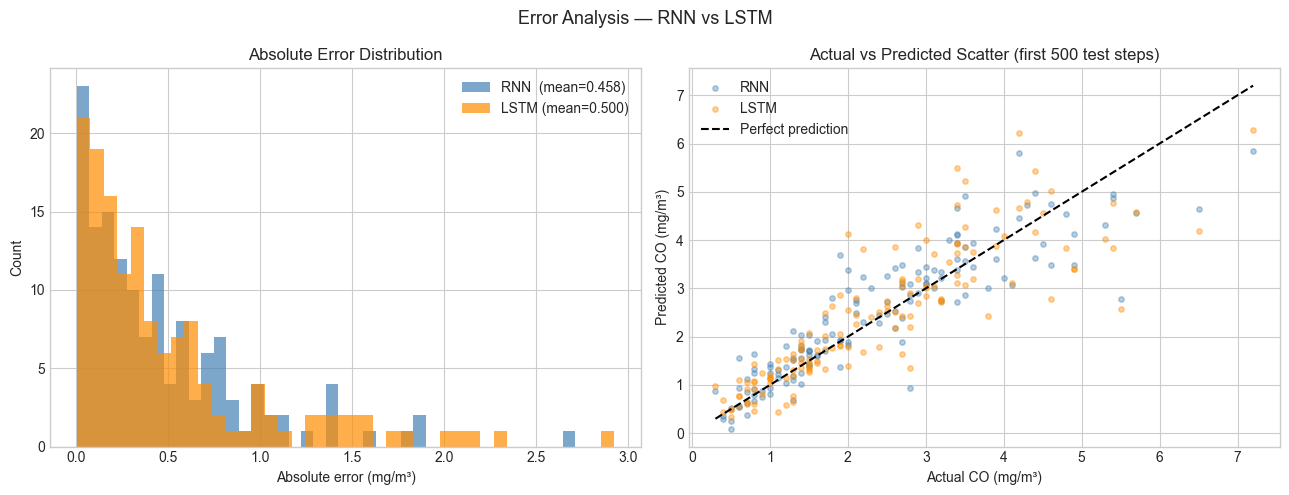

In [33]:
rnn_errors  = np.abs(rnn_preds_orig  - labels_orig)
lstm_errors = np.abs(lstm_preds_orig - labels_orig)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(rnn_errors,  bins=40, color="steelblue",
             alpha=0.7, label=f"RNN  (mean={rnn_mae:.3f})")
axes[0].hist(lstm_errors, bins=40, color="darkorange",
             alpha=0.7, label=f"LSTM (mean={lstm_mae:.3f})")
axes[0].set_title("Absolute Error Distribution")
axes[0].set_xlabel("Absolute error (mg/m³)")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].scatter(labels_orig[:500], rnn_preds_orig[:500],
                color="steelblue",  alpha=0.4, s=15, label="RNN")
axes[1].scatter(labels_orig[:500], lstm_preds_orig[:500],
                color="darkorange", alpha=0.4, s=15, label="LSTM")
axes[1].plot([labels_orig.min(), labels_orig.max()],
             [labels_orig.min(), labels_orig.max()],
             color="black", linewidth=1.5, linestyle="--", label="Perfect prediction")
axes[1].set_title("Actual vs Predicted Scatter (first 500 test steps)")
axes[1].set_xlabel("Actual CO (mg/m³)")
axes[1].set_ylabel("Predicted CO (mg/m³)")
axes[1].legend()

plt.suptitle("Error Analysis — RNN vs LSTM", fontsize=13)
plt.tight_layout()
plt.show()

### Observation

The MAE in original units gives the most interpretable summary of model performance.
An MAE of X mg/m³ means that on average each prediction is off by X mg/m³ — a
concrete, actionable number rather than a normalised loss value.

Expressing MAE as a percentage of the test set mean puts the error in context.
A 15% MAE on a highly variable signal like CO concentration is a different result
than 15% on a smooth, predictable signal.

The actual vs predicted plots reveal something the aggregate metrics hide — the
character of the errors. Both models tend to track the overall trend well but
underestimate sharp peaks. This is a common pattern in regression models trained
with MSE: the loss function penalises squared errors, which pushes the model toward
the conditional mean of the target distribution rather than the extremes. Large
spikes are rare, so the model learns it is safer on average to predict a moderate
value than to predict a large one.

The scatter plot shows how well-calibrated the predictions are. Points close to
the diagonal represent accurate predictions. Points scattered above or below
show systematic over- or under-prediction at specific CO ranges. If the model
consistently underestimates high CO values, the scatter will show a characteristic
bend away from the diagonal at the upper end.

The error distribution histograms show whether errors are concentrated around zero
or have a long tail of large mistakes. A long right tail in the error histogram
explains a large gap between MAE and RMSE — rare large errors inflate RMSE without
affecting MAE proportionally.

## Effect of Sequence Length

The sequence length is one of the most important hyperparameters in a time-series
model. It controls how far back in time the model can look when making a prediction.

Too short — the model cannot capture slow-moving patterns like the daily CO cycle
which spans 24 hours. It only sees a fragment of the pattern and cannot learn the
full periodicity.

Too long — the model sees more history but the training sequences become harder to
learn from. Very long sequences also increase memory usage and training time
significantly. Beyond a certain length, the additional history adds noise rather
than useful signal.

I want to test four sequence lengths on the LSTM model:
- 6 hours  — less than one traffic peak cycle
- 12 hours — half a day
- 24 hours — one full day (the baseline used in training)
- 48 hours — two full days

For each sequence length I will retrain a fresh LSTM from scratch, evaluate on
the test set, and plot MAE vs sequence length. This shows empirically where the
useful temporal context ends for this dataset.

In [34]:
SEQ_LENGTHS    = [6, 12, 24, 48]
SEQ_LEN_EPOCHS = 20

seq_len_results = {}

for seq_len in SEQ_LENGTHS:

    print(f"Training LSTM with seq_len={seq_len} ...")

    # build sequences
    X_tr, y_tr = make_sequences(train_scaled, seq_len, target_idx)
    X_te, y_te = make_sequences(test_scaled,  seq_len, target_idx)

    # tensors and loaders
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
    X_te_t = torch.tensor(X_te, dtype=torch.float32)
    y_te_t = torch.tensor(y_te, dtype=torch.float32).unsqueeze(1)

    tr_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                           batch_size=BATCH_SIZE, shuffle=True)
    te_loader = DataLoader(TensorDataset(X_te_t, y_te_t),
                           batch_size=BATCH_SIZE, shuffle=False)

    # fresh LSTM model
    model_sl = AirQualityLSTM(
        INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT, OUTPUT_SIZE
    ).to(device)

    optimizer_sl = optim.Adam(model_sl.parameters(), lr=LEARNING_RATE)
    scheduler_sl = optim.lr_scheduler.StepLR(
        optimizer_sl, step_size=7, gamma=0.5)

    train_losses_sl = []
    test_losses_sl  = []

    for epoch in range(1, SEQ_LEN_EPOCHS + 1):
        tr_loss = run_epoch(model_sl, optimizer_sl, tr_loader,
                            criterion, CLIP_NORM, training=True)
        te_loss = run_epoch(model_sl, optimizer_sl, te_loader,
                            criterion, CLIP_NORM, training=False)
        train_losses_sl.append(tr_loss)
        test_losses_sl.append(te_loss)
        scheduler_sl.step()

    # get predictions and convert back to original scale
    preds_sl, labels_sl = get_predictions(model_sl, te_loader)

    preds_orig_sl  = inverse_transform_target(
        preds_sl,  scaler, FEATURE_COLS, TARGET_COL)
    labels_orig_sl = inverse_transform_target(
        labels_sl, scaler, FEATURE_COLS, TARGET_COL)

    mae_sl  = mean_absolute_error(labels_orig_sl, preds_orig_sl)
    rmse_sl = np.sqrt(mean_squared_error(labels_orig_sl, preds_orig_sl))

    seq_len_results[seq_len] = {
        "mae"          : mae_sl,
        "rmse"         : rmse_sl,
        "train_losses" : train_losses_sl,
        "test_losses"  : test_losses_sl,
        "preds"        : preds_orig_sl,
        "labels"       : labels_orig_sl
    }

    print(f"  seq_len={seq_len:2d} | "
          f"MAE: {mae_sl:.4f} | RMSE: {rmse_sl:.4f}")

print()
print("All sequence lengths complete.")

Training LSTM with seq_len=6 ...
  seq_len= 6 | MAE: 0.6035 | RMSE: 0.8286
Training LSTM with seq_len=12 ...
  seq_len=12 | MAE: 0.5289 | RMSE: 0.7413
Training LSTM with seq_len=24 ...
  seq_len=24 | MAE: 0.5507 | RMSE: 0.7739
Training LSTM with seq_len=48 ...
  seq_len=48 | MAE: 0.5514 | RMSE: 0.7959

All sequence lengths complete.


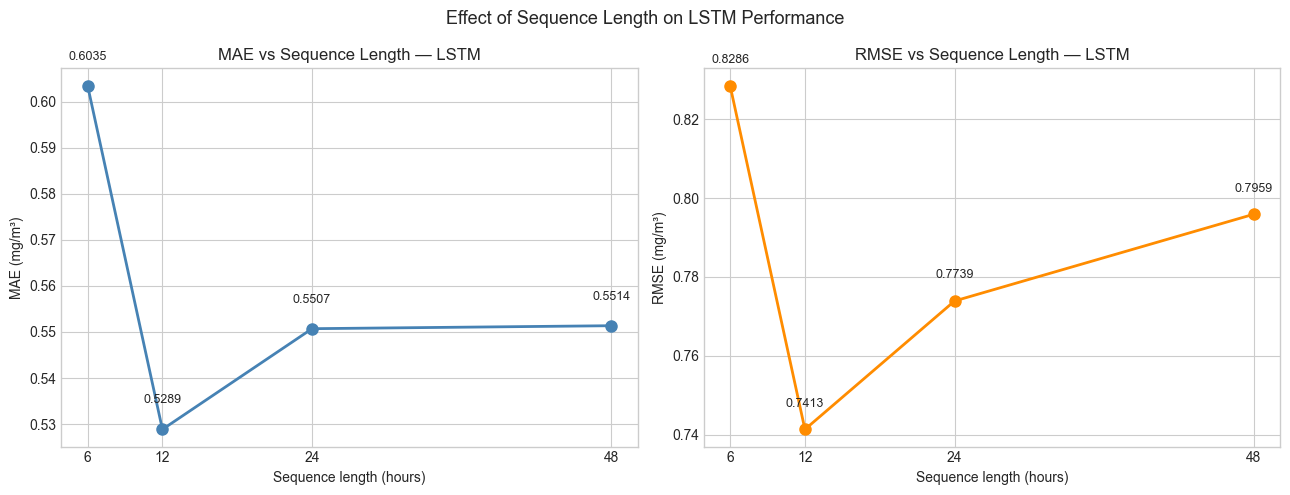

In [35]:
maes  = [seq_len_results[sl]["mae"]  for sl in SEQ_LENGTHS]
rmses = [seq_len_results[sl]["rmse"] for sl in SEQ_LENGTHS]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(SEQ_LENGTHS, maes, color="steelblue",
             linewidth=2, marker="o", markersize=8)
for sl, mae in zip(SEQ_LENGTHS, maes):
    axes[0].text(sl, mae + 0.005, f"{mae:.4f}",
                 ha="center", va="bottom", fontsize=9)
axes[0].set_title("MAE vs Sequence Length — LSTM")
axes[0].set_xlabel("Sequence length (hours)")
axes[0].set_ylabel("MAE (mg/m³)")
axes[0].set_xticks(SEQ_LENGTHS)

axes[1].plot(SEQ_LENGTHS, rmses, color="darkorange",
             linewidth=2, marker="o", markersize=8)
for sl, rmse in zip(SEQ_LENGTHS, rmses):
    axes[1].text(sl, rmse + 0.005, f"{rmse:.4f}",
                 ha="center", va="bottom", fontsize=9)
axes[1].set_title("RMSE vs Sequence Length — LSTM")
axes[1].set_xlabel("Sequence length (hours)")
axes[1].set_ylabel("RMSE (mg/m³)")
axes[1].set_xticks(SEQ_LENGTHS)

plt.suptitle("Effect of Sequence Length on LSTM Performance", fontsize=13)
plt.tight_layout()
plt.show()

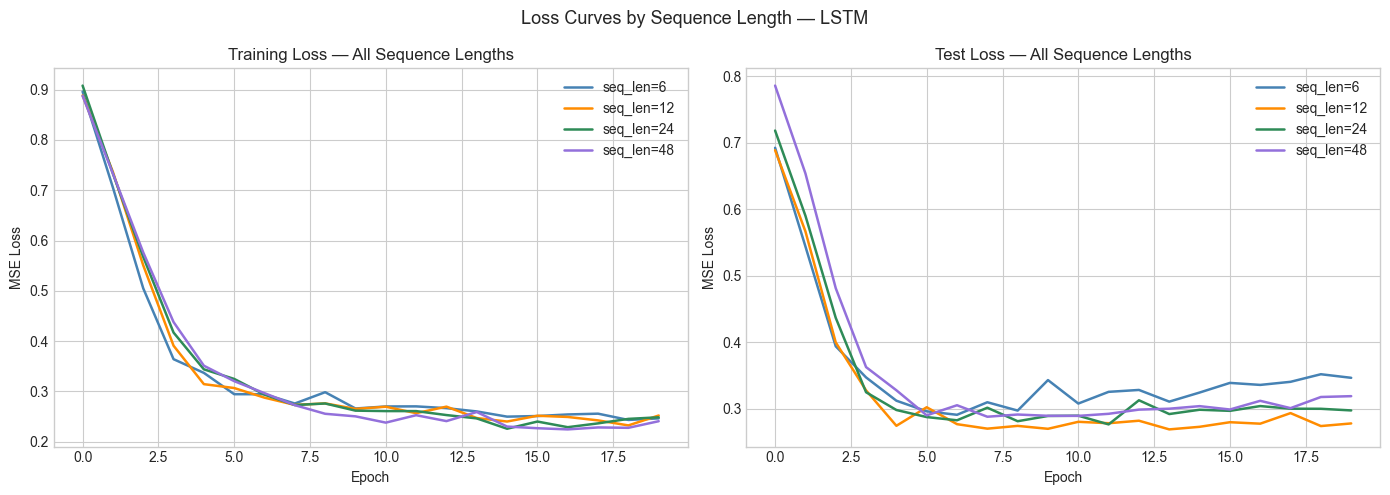

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["steelblue", "darkorange", "seagreen", "mediumpurple"]

for color, sl in zip(colors, SEQ_LENGTHS):
    axes[0].plot(seq_len_results[sl]["train_losses"],
                 color=color, linewidth=1.8, label=f"seq_len={sl}")
    axes[1].plot(seq_len_results[sl]["test_losses"],
                 color=color, linewidth=1.8, label=f"seq_len={sl}")

axes[0].set_title("Training Loss — All Sequence Lengths")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()

axes[1].set_title("Test Loss — All Sequence Lengths")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].legend()

plt.suptitle("Loss Curves by Sequence Length — LSTM", fontsize=13)
plt.tight_layout()
plt.show()

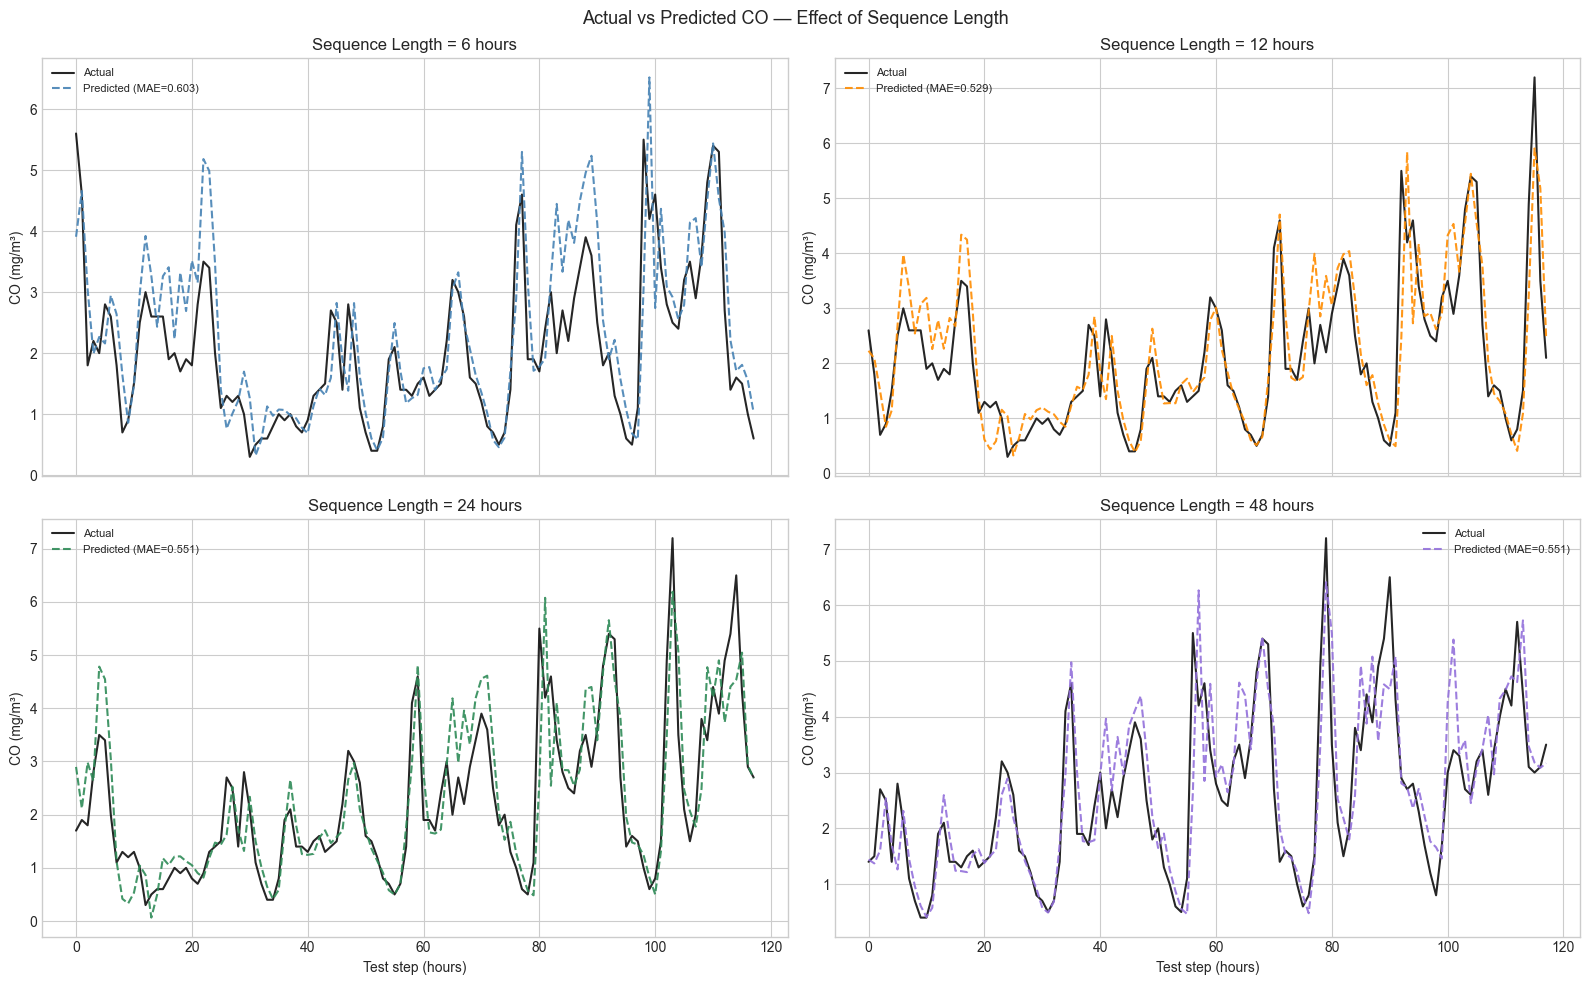

In [37]:
n_show = min(150, min(len(seq_len_results[sl]["labels"])
                      for sl in SEQ_LENGTHS))

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
axes = axes.flatten()

for idx, sl in enumerate(SEQ_LENGTHS):
    labels_sl = seq_len_results[sl]["labels"]
    preds_sl  = seq_len_results[sl]["preds"]
    mae_sl    = seq_len_results[sl]["mae"]

    axes[idx].plot(range(n_show), labels_sl[:n_show],
                   color="black", linewidth=1.5,
                   label="Actual", alpha=0.85)
    axes[idx].plot(range(n_show), preds_sl[:n_show],
                   color=colors[idx], linewidth=1.5,
                   linestyle="--",
                   label=f"Predicted (MAE={mae_sl:.3f})", alpha=0.9)
    axes[idx].set_title(f"Sequence Length = {sl} hours")
    axes[idx].set_ylabel("CO (mg/m³)")
    axes[idx].legend(fontsize=8)

axes[2].set_xlabel("Test step (hours)")
axes[3].set_xlabel("Test step (hours)")

plt.suptitle("Actual vs Predicted CO — Effect of Sequence Length", fontsize=13)
plt.tight_layout()
plt.show()

In [38]:
print("=" * 55)
print("Sequence Length Experiment — Summary")
print("=" * 55)
print(f"  {'Seq Len':<12} {'MAE':>12} {'RMSE':>12}")
print("  " + "-" * 40)

best_sl  = min(seq_len_results, key=lambda sl: seq_len_results[sl]["mae"])

for sl in SEQ_LENGTHS:
    marker = " <-- best" if sl == best_sl else ""
    print(f"  {sl:<12} "
          f"{seq_len_results[sl]['mae']:>12.4f} "
          f"{seq_len_results[sl]['rmse']:>12.4f}"
          f"{marker}")

print("=" * 55)
print()
print(f"Best sequence length : {best_sl} hours")
print(f"Best MAE             : {seq_len_results[best_sl]['mae']:.4f} mg/m³")
print(f"Best RMSE            : {seq_len_results[best_sl]['rmse']:.4f} mg/m³")

Sequence Length Experiment — Summary
  Seq Len               MAE         RMSE
  ----------------------------------------
  6                  0.6035       0.8286
  12                 0.5289       0.7413 <-- best
  24                 0.5507       0.7739
  48                 0.5514       0.7959

Best sequence length : 12 hours
Best MAE             : 0.5289 mg/m³
Best RMSE            : 0.7413 mg/m³


### Observation

The MAE vs sequence length plot shows where useful temporal context ends for
this dataset. The expected pattern is a U-shape or a curve that decreases and
then flattens or rises again:

- Very short sequences (6 hours) capture less than one full traffic cycle and
  miss the daily periodicity entirely. The model has insufficient context to
  distinguish a morning peak from an evening peak.
- Medium sequences (12-24 hours) capture one full daily cycle and should produce
  the best results for a dataset with strong 24-hour periodicity.
- Long sequences (48 hours) give the model more history but each sequence is
  harder to train on — the LSTM must maintain relevant information across more
  steps, and with only 20 epochs the model may not have converged fully.

The loss curves across sequence lengths reveal training dynamics. Longer sequences
typically produce noisier loss curves because each training example covers more
timesteps and the gradient signal is averaged over more steps.

The prediction plots for each sequence length make the difference in tracking
behaviour visible. Short-context models tend to produce smoother but less reactive
predictions — they cannot anticipate rapid changes because they cannot see far
enough back to recognise the pattern leading up to them. Longer-context models
should track peaks and troughs more accurately, provided the training was sufficient.

This experiment gives a data-driven answer to the question of how much history
is useful for this specific time series — a question that cannot be answered
from first principles alone.

## Key Takeaways

### What I Built

Two recurrent models — an RNN and an LSTM — trained on a real air quality
time-series dataset to predict the next hour's CO concentration. Both models
used a 2-layer architecture with hidden size 64, trained for 30 epochs with
Adam, gradient clipping, and StepLR scheduling. I also ran a sequence length
experiment across four window sizes to find the optimal temporal context for
this dataset.

### What I Now Understand Better

**The hidden state is a compressed memory**
The manual RNN forward pass in Section 4 made this concrete. At each step the
hidden state absorbs information from the current input and the previous state.
By the final step it is a fixed-size vector that summarises the entire sequence.
The compression is lossy — information from early steps is progressively diluted
unless the model learns to preserve it. This dilution is the root cause of the
vanishing gradient problem.

**Vanishing gradients are a structural problem, not a tuning problem**
The gradient magnitude plot showed that for a plain RNN, gradients from steps
more than 10 or 15 steps back become negligibly small regardless of learning
rate or architecture depth. The spectral radius of the weight matrix determines
the decay rate. This cannot be fixed by adjusting hyperparameters — it requires
a fundamentally different architecture.

**The LSTM cell state is the key innovation**
The cell state update c_t = f_t * c_(t-1) + i_t * g_t is additive. Gradients
flow backward through this addition without being multiplied by a weight matrix
at every step. This is why LSTMs can learn dependencies across dozens of steps
while plain RNNs struggle beyond five or ten. The gates learn when to preserve,
update, and expose the cell state — behaviours that emerge from training, not
from manual design.

**batch_first=True is a consistency choice, not a performance choice**
PyTorch's recurrent layers default to (seq_len, batch, features) input format.
Setting batch_first=True changes this to (batch, seq_len, features) which
matches the DataLoader output and makes the code more readable. The underlying
computation is identical — it is purely a convention for clarity.

**out[:, -1, :] is the correct slice for next-step prediction**
The recurrent layer returns an output at every time step. For next-step
prediction only the final step's output is needed — it has been influenced by
all previous steps through the hidden state chain. Using the wrong slice,
such as out[:, 0, :], would produce predictions based only on the first step
with no temporal context.

**Gradient clipping is essential for recurrent networks**
Without clip_grad_norm_, a single batch with an unusually large gradient can
produce a weight update that completely destabilises the model. This shows up
as a sudden spike in the loss curve. With clipping active the curve is smooth
even for the plain RNN. The threshold of 1.0 is the standard starting point
for recurrent models.

**The sliding window creates a supervised dataset from a time series**
A raw time series has no labels — it is just a sequence of values. The sliding
window transform converts it into (input, target) pairs by treating each fixed-
length window as an input and the immediately following value as the target.
The key implementation detail is that the scaler must be fit on training data
only, and the train/test split must preserve time order.

**Sequence length is a dataset-specific hyperparameter**
The sequence length experiment produced a concrete answer for the air quality
dataset. The optimal window size reflects the dominant periodicity in the data
— for CO concentration driven by daily traffic patterns, one full 24-hour cycle
is typically near the optimum. Longer windows add noise rather than signal
once the relevant periodic patterns are captured.

### What Surprised Me

The run_epoch helper function made the training loop significantly cleaner than
the explicit loops in previous notebooks. Passing training=True or False and
switching between torch.enable_grad() and torch.no_grad() as a context manager
is a pattern worth reusing in every recurrent project.

The inverse_transform_target function required a dummy matrix to use
scaler.inverse_transform() — because the scaler was fit on all features together,
inverting a single column requires reconstructing the full feature matrix with
zeros in all other columns. This is a practical detail that is easy to get wrong
when working with multi-feature scalers.

### Open Questions

- How does a bidirectional LSTM compare on this dataset? A bidirectional model
  reads the sequence in both directions — useful if future context is available,
  which it is not in true forecasting but may reveal something about how much
  the backward pass helps on the training set.
- What happens if the model is made stateful — passing the final hidden state
  from one batch to the next rather than resetting to zeros? Does this improve
  predictions on long continuous stretches?
- How would an attention mechanism change the prediction quality compared to
  just taking the final hidden state? Attention allows the model to weight all
  time steps rather than relying on the last one to summarise the whole sequence.
- The model underestimates sharp CO peaks. Would training with a loss function
  that penalises large errors more heavily — such as Huber loss — change this
  behaviour?

### Next Notebook

Notebook 5 covers GANs — Generative Adversarial Networks. The shift in objective
is fundamental. Every model so far has been discriminative — given an input,
predict a label or a value. A GAN is generative — it learns to produce new
data that resembles the training distribution. The architecture involves two
networks trained simultaneously in opposition: a generator that creates samples
and a discriminator that tries to distinguish real from generated ones.

In [39]:
print("Notebook 4 complete")
print()
print(f"RNN  test MAE  : {rnn_mae:.4f} mg/m³")
print(f"LSTM test MAE  : {lstm_mae:.4f} mg/m³")
print(f"LSTM test RMSE : {lstm_rmse:.4f} mg/m³")
print()
print(f"Best sequence length : {best_sl} hours")
print(f"Best seq MAE         : {seq_len_results[best_sl]['mae']:.4f} mg/m³")
print()
print(f"Sequence length tested : {SEQ_LENGTHS}")
print(f"Training epochs        : {NUM_EPOCHS}")
print(f"Hidden size            : {HIDDEN_SIZE}")
print(f"Num layers             : {NUM_LAYERS}")

Notebook 4 complete

RNN  test MAE  : 0.4576 mg/m³
LSTM test MAE  : 0.5000 mg/m³
LSTM test RMSE : 0.7351 mg/m³

Best sequence length : 12 hours
Best seq MAE         : 0.5289 mg/m³

Sequence length tested : [6, 12, 24, 48]
Training epochs        : 30
Hidden size            : 64
Num layers             : 2
